<a href="https://colab.research.google.com/github/JordanCodeGit/Geo-SentimentCafeAnalysis/blob/main/Analisis_Geo_Sentimen_Kafe_Purwokerto_Kelompok_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Analisis Geo-Sentimen dan Pemodelan Topik Ulasan Pelanggan Kafe dan Kedai Kopi
## Komparasi Spasial Kawasan Pendidikan dan Pariwisata di Purwokerto
### By Jordan Angkawijaya (2311102139) & Naswa Malika Putri (2311102232)
| | |
|---|---|
| **Mata Kuliah** | Natural Language Processing (NLP) |
| **Fakultas** | Informatika — SI Teknik Informatika, Kampus Purwokerto |
| **Kode Tugas** | CAK4NBB3-PSIIF-10-REG01 |
| **Semester** | 2526/2 |

---

##  Alur Analisis (CRISP-DM)
1. **Business Understanding** — Identifikasi permasalahan dan tujuan analisis
2. **Data Collection** — Scraping 350 ulasan per cafe (total 20 cafe) via Apify Google Maps
3. **Text Processing** — Case Folding → Cleaning → Tokenisasi → Stopword Removal → Stemming
4. **EDA** — Visualisasi distribusi, tren, heatmap, dan peta geo-spasial interaktif

---
##  Business Understanding

### 1.1 Latar Belakang
Purwokerto merupakan kota yang berkembang pesat dengan dua karakter kawasan utama:
- **Kawasan Pendidikan** — area sekitar Telkom University, Unsoed, dan UMP yang didominasi oleh mahasiswa dan civitas akademika. Kafe di kawasan ini melayani segmen anak muda yang mencari tempat belajar, nongkrong, dan WFC (Work From Cafe).
- **Kawasan Pariwisata** — area Baturraden dengan daya tarik wisata alam Gunung Slamet. Kafe di kawasan ini melayani wisatawan yang mencari pengalaman kuliner dengan suasana alam.

Perbedaan segmen pelanggan ini diperkirakan menghasilkan pola sentimen dan topik ulasan yang berbeda secara signifikan.

### 1.2 Business Questions
1. Bagaimana **distribusi sentimen** (positif/netral/negatif) ulasan pelanggan kafe di Kawasan Pendidikan dibandingkan Kawasan Pariwisata Baturraden?
2. **Topik** apa saja yang paling dominan dibicarakan pelanggan di masing-masing kawasan?
3. Apakah terdapat **pola spasial** (geografis) dalam sentimen ulasan kafe di Purwokerto?
4. Faktor apa yang paling memengaruhi kepuasan pelanggan di kedua kawasan?

### 1.3 Tujuan Analisis
- Melakukan **geo-sentiment analysis** berbasis ulasan Google Maps
- Membandingkan sentimen positif, negatif, dan netral antar kawasan secara kuantitatif
- Membuat **peta sebaran sentimen** berbasis koordinat GPS lokasi cafe
- Mengidentifikasi **kata kunci dan topik dominan** per kawasan melalui EDA mendalam

### 1.4 Hipotesis Penelitian
- Terdapat perbedaan signifikan pada topik keluhan pelanggan berdasarkan letak geografis; kawasan pendidikan didominasi isu infrastruktur (lahan parkir, konektivitas/Wi-Fi), sedangkan kawasan pariwisata didominasi isu aksesibilitas (kondisi jalan, kemacetan).
- Ulasan negatif pada kawasan pariwisata lebih berfokus pada ketidaksesuaian antara harga dan pengalaman (suasana/pemandangan) dibandingkan kawasan pendidikan.

### 1.5 Sumber Data
- **Platform**: Google Maps Reviews
- **Tool scraping**: Apify (`compass/google-maps-reviews-scraper`)
- **Target**: 20 kafe — 10 Kawasan Pendidikan + 10 Kawasan Pariwisata Baturraden
- **Volume**: **350 ulasan per cafe** (total target ±7.000 ulasan)
- **Parameter**: `language='id'`, `reviewsSort='newest'`, `maxReviews=350`

---
##  FASE I: DATA ENGINEERING & TEMPORAL SEPARATION

In [ ]:
# ============================================================
# CELL 1 — Environment Setup & Dependencies Installation
# Instalasi modul krusial untuk ekstraksi spasial, pemrosesan teks,
# serta manipulasi kelas matriks komputasi.
# ============================================================
import sys

print("Memulai instalasi pustaka...")

# Klien API Apify untuk ekstraksi ulasan Google Maps
!{sys.executable} -m pip install -q apify-client

# Sastrawi untuk algoritma stemming bahasa Indonesia
!{sys.executable} -m pip install -q Sastrawi

# Imbalanced-learn untuk eksekusi algoritma RandomUnderSampler
!{sys.executable} -m pip install -q imbalanced-learn

# Folium untuk visualisasi dashboard geospasial
!{sys.executable} -m pip install -q folium

print("✅ Seluruh instalasi pustaka berhasil dieksekusi.")

In [ ]:
# ============================================================
# CELL 2 — Library Matrix Ingestion
# Mengimpor seluruh modul komputasi, pemrosesan bahasa alami,
# algoritma klasifikasi, dan visualisasi spasial.
# ============================================================
import pandas as pd
import numpy as np
import re
import string
import warnings
from datetime import datetime
import time

# Modul Visualisasi & Spasial
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium import plugins

# Modul NLP (Natural Language Processing)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Klien API Ekstraksi Data Google Maps
from apify_client import ApifyClient

# Modul Machine Learning & Evaluasi Data
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from imblearn.under_sampling import RandomUnderSampler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.decomposition import LatentDirichletAllocation

# 1. Konfigurasi Lingkungan Global
# Mematikan peringatan deprecation pustaka agar output presentasi sidang tetap bersih
warnings.filterwarnings('ignore')

# 2. Inisialisasi Resource NLTK
# Diunduh secara senyap (quiet=True) untuk menghindari log teks yang panjang
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("✅ Library Matrix berhasil diinisialisasi. Mesin siap menerima instruksi ekstraksi.")

✅ Library Matrix berhasil diinisialisasi. Mesin siap menerima instruksi ekstraksi.


In [ ]:
# ============================================================
# CELL 3 — Apify Gateway Initialization
# Mengonfigurasi jembatan otentikasi aman untuk mengakses peladen
# scraper ulasan Google Maps.
# ============================================================
from google.colab import userdata
from apify_client import ApifyClient

print("Menginisialisasi gerbang akses Apify Client...")

# Mengambil API Token secara aman dari fitur Secrets (ikon kunci) di Google Colab
# Pastikan Anda telah menambahkan rahasia dengan nama 'APIFY_API_TOKEN'
try:
    APIFY_TOKEN = userdata.get('APIFY_API_TOKEN')

    # Inisialisasi Klien Utama
    client = ApifyClient(APIFY_TOKEN)
    print("✅ Apify Client berhasil terotentikasi dan aktif.")

except Exception as e:
    print("❌ Gagal memuat API Token dari Secrets.")
    print("Gunakan pendekatan cadangan: Membaca token string manual.")

    # Pendekatan Cadangan jika fitur Secrets belum dikonfigurasi
    # Ganti string di bawah ini dengan token asli Anda jika diperlukan
    APIFY_TOKEN_MANUAL = "MASUKKAN_TOKEN_APIFY_ANDA_DI_SINI"

    if APIFY_TOKEN_MANUAL != "MASUKKAN_TOKEN_APIFY_ANDA_DI_SINI":
        client = ApifyClient(APIFY_TOKEN_MANUAL)
        print("✅ Apify Client berhasil diinisialisasi melalui jalur manual.")
    else:
        print("⚠ Peringatan: Token belum diisi. Proses scraping pada Cell 6 akan gagal.")

Menginisialisasi gerbang akses Apify Client...
✅ Apify Client berhasil terotentikasi dan aktif.


In [ ]:
# ============================================================
# CELL 4 — Geolocation Master Data
# Definisi parameter pencarian untuk 20 objek kafe Purwokerto.
# Struktur dictionary dirancang agar kompatibel dengan input API.
# ============================================================

print("Memuat Master Data Geospasial Kafe...")

daftar_cafe = [
    # --------------------------------------------------------
    # KAWASAN PARIWISATA (Zona Baturraden & Sekitarnya)
    # --------------------------------------------------------
    {"nama_cafe": "Ebony Cafe", "kawasan": "Kawasan Pariwisata", "search_query": "Ebony Cafe Baturraden Purwokerto"},
    {"nama_cafe": "MASSAPI", "kawasan": "Kawasan Pariwisata", "search_query": "MASSAPI Cafe Baturraden"},
    {"nama_cafe": "Penak Mawon", "kawasan": "Kawasan Pariwisata", "search_query": "Penak Mawon Baturraden"},
    {"nama_cafe": "Cerita Alam Resto", "kawasan": "Kawasan Pariwisata", "search_query": "Cerita Alam Cafe Resto Baturraden"},
    {"nama_cafe": "Taman Langit Restaurant", "kawasan": "Kawasan Pariwisata", "search_query": "Taman Langit Cafe Purwokerto"},
    {"nama_cafe": "New Kalarasa Resto & Coffee", "kawasan": "Kawasan Pariwisata", "search_query": "New Kalarasa Resto & Coffee Purwokerto"},
    {"nama_cafe": "Layana Kopi", "kawasan": "Kawasan Pariwisata", "search_query": "Layana Kopi Baturraden"},
    {"nama_cafe": "Lembah Patih", "kawasan": "Kawasan Pariwisata", "search_query": "Lembah Patih Baturraden"},
    {"nama_cafe": "Polaris Coffee & Resto", "kawasan": "Kawasan Pariwisata", "search_query": "Polaris Coffee & Resto Purwokerto"},
    {"nama_cafe": "Kopi Kami untuk Kamu", "kawasan": "Kawasan Pariwisata", "search_query": "Kopi Kami untuk Kamu Baturraden"},

    # --------------------------------------------------------
    # KAWASAN PENDIDIKAN (Zona Kampus & Pusat Kota)
    # --------------------------------------------------------
    {"nama_cafe": "Arasta Alpha Overste Isdiman", "kawasan": "Kawasan Pendidikan", "search_query": "Arasta Alpha Overste Isdiman Purwokerto"},
    {"nama_cafe": "Society Coffee House", "kawasan": "Kawasan Pendidikan", "search_query": "Society Coffee House Purwokerto"},
    {"nama_cafe": "Kopi Arasta Hotel Wisata Niaga", "kawasan": "Kawasan Pendidikan", "search_query": "Kopi Arasta Hotel Wisata Niaga Purwokerto"},
    {"nama_cafe": "Praketa", "kawasan": "Kawasan Pendidikan", "search_query": "Praketa Kopi Purwokerto"},
    {"nama_cafe": "At Cafe Campus", "kawasan": "Kawasan Pendidikan", "search_query": "At Cafe Campus Purwokerto"},
    {"nama_cafe": "Lav Cafe Purwokerto", "kawasan": "Kawasan Pendidikan", "search_query": "Lav Cafe Purwokerto"},
    {"nama_cafe": "Elskoffie", "kawasan": "Kawasan Pendidikan", "search_query": "Elskoffie Purwokerto"},
    {"nama_cafe": "Alas House", "kawasan": "Kawasan Pendidikan", "search_query": "Alas House Purwokerto"},
    {"nama_cafe": "Mimosa Coffee Kitchen & Dessert", "kawasan": "Kawasan Pendidikan", "search_query": "Mimosa Coffee Kitchen Purwokerto"},
    {"nama_cafe": "et al Coffee Purwokerto", "kawasan": "Kawasan Pendidikan", "search_query": "et al Coffee Purwokerto"}
]

# Verifikasi integritas dimensi data
jumlah_pariwisata = sum(1 for c in daftar_cafe if c['kawasan'] == 'Kawasan Pariwisata')
jumlah_pendidikan = sum(1 for c in daftar_cafe if c['kawasan'] == 'Kawasan Pendidikan')

print(f"Total target ekstraksi: {len(daftar_cafe)} Kafe")
print(f"Distribusi: {jumlah_pariwisata} Kawasan Pariwisata | {jumlah_pendidikan} Kawasan Pendidikan")
print("✅ Parameter Geolocation Master Data siap dikirimkan ke mesin Scraper.")

Memuat Master Data Geospasial Kafe...
Total target ekstraksi: 20 Kafe
Distribusi: 10 Kawasan Pariwisata | 10 Kawasan Pendidikan
✅ Parameter Geolocation Master Data siap dikirimkan ke mesin Scraper.


In [ ]:
# ============================================================
# CELL 5 — Automated Scraper Engine
# Definisi fungsi untuk mengeksekusi ekstraksi via Apify API.
# Dilengkapi parameter sorting kronologis dan pencegahan translasi.
# ============================================================

def ekstrak_ulasan_gmaps(apify_client, query_pencarian, batas_maksimal=500):
    """
    Menarik ulasan dari Google Maps berdasarkan string pencarian.

    Parameter:
    - apify_client: Objek ApifyClient yang sudah terotentikasi.
    - query_pencarian: Nama kafe + kawasan (contoh: "Society Coffee House Purwokerto").
    - batas_maksimal: Jumlah maksimal ulasan yang ditarik (500 cukup untuk mencapai 2024).
    """

    # Konfigurasi Payload API dengan ketat
    konfigurasi_ekstraksi = {
        "searchStringsArray": [query_pencarian],
        "maxCrawledPlacesPerSearch": 1,
        "maxReviews": batas_maksimal,
        "language": "id",
        "reviewsSort": "newest",           # KUNCI TEMPORAL: Urutkan dari yang paling baru
        "reviewsTranslation": "original",  # Mencegah Google menerjemahkan slang lokal
        "scrapeReviewerId": False,
        "scrapeResponseFromOwner": False
    }

    print(f"Mengeksekusi penarikan data: {query_pencarian} ...")

    hasil_ulasan = []

    try:
        # Panggil Actor 'drobnikj/google-maps-scraper'
        # Actor ini adalah standar industri untuk ekstraksi Google Maps
        eksekusi = apify_client.actor("drobnikj/google-maps-scraper").call(run_input=konfigurasi_ekstraksi)

        # Iterasi melalui dataset hasil ekstraksi di penyimpanan Apify
        for item in apify_client.dataset(eksekusi["defaultDatasetId"]).iterate_items():
            ulasan_mentah = item.get('reviews', [])

            for ulasan in ulasan_mentah:
                teks = ulasan.get('text', '')

                # Saring data: Abaikan ulasan yang hanya berisi bintang tanpa teks
                if teks and isinstance(teks, str) and len(teks.strip()) > 5:
                    hasil_ulasan.append({
                        'nama_pengguna': ulasan.get('name', 'Anonim'),
                        'rating': ulasan.get('stars', 0),
                        'waktu_ulasan': ulasan.get('publishedAtDate', ''),
                        'isi_ulasan': teks.strip()
                    })

        print(f"✓ Berhasil mengekstrak {len(hasil_ulasan)} ulasan valid (memiliki teks).")
        return hasil_ulasan

    except Exception as e:
        print(f"❌ Terjadi kesalahan saat mengekstrak '{query_pencarian}': {str(e)}")
        return []

print("✅ Modul Automated Scraper Engine berhasil dikompilasi.")

✅ Modul Automated Scraper Engine berhasil dikompilasi.


In [ ]:
# ============================================================
# CELL 6 — Storage Compilation & Extraction (PATCHED v3)
# Metode: Dynamic Metadata Harvesting & Unified Dataset Compilation
# Optimisasi: Object-Oriented Extraction (Apify Client Update)
# ============================================================
import pandas as pd
import numpy as np
import time
from datetime import datetime

print("=== MEMULAI PROSES LIVE SCRAPING & KOMPILASI DATA ===")
print(f"Waktu Eksekusi Sistem: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Mesin sedang memanen data ulasan beserta koordinat spasial secara otomatis.\n")

master_records = []

# Iterasi secara linier melewati 20 parameter geolocation master data
for idx, cafe in enumerate(daftar_cafe, 1):
    nama = cafe['nama_cafe']
    kawasan = cafe['kawasan']
    kueri = cafe['search_query']

    print(f"[{idx}/{len(daftar_cafe)}] Memproses Ekstraksi: {nama} ({kawasan})")

    # Injeksi parameter ketat: Mengunci penyortiran kronologis mundur dari Juni 2026
    konfigurasi_payload = {
        "searchStringsArray": [kueri],
        "maxCrawledPlacesPerSearch": 1,
        "maxReviews": 500,
        "language": "id",
        "reviewsSort": "newest",
        "reviewsTranslation": "original",
        "scrapeReviewerId": False,
        "scrapeResponseFromOwner": False
    }

    try:
        # EKSEKUSI API PATCHED
        run = client.actor("compass/crawler-google-places").call(run_input=konfigurasi_payload)

        # PERBAIKAN BUG STRUKTUR OBJEK: Menggunakan dot notation 'default_dataset_id'
        dataset_id = run.default_dataset_id

        # Ambil hasil dari storage dataset peladen
        items = list(client.dataset(dataset_id).iterate_items())

        if not items:
            print(f"  ⚠ Kueri '{kueri}' tidak ditemukan di Google Maps.")
            continue

        for item in items:
            # INTEGRASI METADATA SPASIAL DYNAMIC: Ekstrak koordinat langsung dari objek tempat
            lat_live = item.get('location', {}).get('lat', np.nan)
            lon_live = item.get('location', {}).get('lng', np.nan)
            rating_global = item.get('totalScore', np.nan)

            reviews_list = item.get('reviews', [])
            valid_reviews_count = 0

            for rev in reviews_list:
                teks_ulasan = rev.get('text', '')

                # Filter Kebisingan: Hanya mengompilasi ulasan yang memiliki teks valid
                if teks_ulasan and isinstance(teks_ulasan, str) and len(teks_ulasan.strip()) > 5:
                    master_records.append({
                        'nama_cafe': nama,
                        'kawasan': kawasan,
                        'lat': lat_live,
                        'lon': lon_live,
                        'rating_gmaps': rating_global,
                        'nama_pengguna': rev.get('name', 'Anonim'),
                        'rating': rev.get('stars', 0),
                        'waktu_ulasan': rev.get('publishedAtDate', ''),
                        'isi_ulasan': teks_ulasan.strip()
                    })
                    valid_reviews_count += 1

            print(f"  ✓ Koordinat Terkunci: [{lat_live}, {lon_live}] | Rating Global: ⭐ {rating_global}")
            print(f"  ✓ Berhasil mengompilasi {valid_reviews_count} ulasan tekstual.")

    except Exception as e:
        print(f"  ❌ Kegagalan Sistem pada '{nama}': {str(e)}")

    # Protokol jeda waktu aman untuk menjaga stabilitas kuota rate-limit API
    time.sleep(1.5)

# 2. Transformasi Array Kategori Menjadi Pandas DataFrame
df_raw = pd.DataFrame(master_records)

print("\n" + "="*60)
print("📊 RINGKASAN DATASET MENTAH BERHASIL DIKOMPILASI")
print("="*60)
if not df_raw.empty:
    print(f"Total Baris Ulasan Valid Terkumpul : {len(df_raw)} data")
    print("\nVolume Ulasan Real-Time Per Objek Kafe:")
    print(df_raw['nama_cafe'].value_counts())
    print("\nDistribusi Volume Data Per Wilayah:")
    print(df_raw['kawasan'].value_counts())

    # Ekspor berkas mentah ke penyimpanan lokal runtime
    df_raw.to_csv('Dataset_Kafe_Purwokerto_Raw.csv', index=False, encoding='utf-8-sig')
    print("\n✅ Berkas murni berhasil diekspor: 'Dataset_Kafe_Purwokerto_Raw.csv'")
else:
    print("❌ Kebocoran Proses: Dataframe kosong. Periksa status otentikasi API Key Anda.")
print("="*60)

=== MEMULAI PROSES LIVE SCRAPING & KOMPILASI DATA ===
Waktu Eksekusi Sistem: 2026-06-09 10:23:40
Mesin sedang memanen data ulasan beserta koordinat spasial secara otomatis.

[1/20] Memproses Ekstraksi: Ebony Cafe (Kawasan Pariwisata)


[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> Status: RUNNING, Message: 
[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> 2026-06-09T10:23:40.825Z ACTOR: Pulling container image of build OsZ2CV4sCQITtJMiJ from registry.
[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> 2026-06-09T10:23:40.827Z ACTOR: Creating container.
[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> 2026-06-09T10:23:40.872Z ACTOR: Starting container.
[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> 2026-06-09T10:23:40.873Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> 2026-06-09T10:23:41.952Z INFO  System info {"apifyVersion":"3.7.2","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.16.0"}
[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> 2026-06-09T10:23:42.360Z INFO  📡 Geolocation started
[apify.crawler-google-places runId:oHUbUaGwW6c4smcHl] -> 2026-06-09T10:23:42.393Z IN

  ✓ Koordinat Terkunci: [-7.3365701, 109.2308175] | Rating Global: ⭐ 4.9
  ✓ Berhasil mengompilasi 309 ulasan tekstual.
[2/20] Memproses Ekstraksi: MASSAPI (Kawasan Pariwisata)


[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> Status: RUNNING, Message: 
[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> 2026-06-09T10:26:02.839Z ACTOR: Pulling container image of build OsZ2CV4sCQITtJMiJ from registry.
[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> 2026-06-09T10:26:02.841Z ACTOR: Creating container.
[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> 2026-06-09T10:26:02.920Z ACTOR: Starting container.
[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> 2026-06-09T10:26:02.922Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> 2026-06-09T10:26:04.195Z INFO  System info {"apifyVersion":"3.7.2","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.16.0"}
[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> 2026-06-09T10:26:04.588Z INFO  📡 Geolocation started
[apify.crawler-google-places runId:fxg3vrSyOvIstBjHW] -> 2026-06-09T10:26:04.613Z IN

  ✓ Koordinat Terkunci: [-7.3129128, 109.2343793] | Rating Global: ⭐ 4.4
  ✓ Berhasil mengompilasi 293 ulasan tekstual.
[3/20] Memproses Ekstraksi: Penak Mawon (Kawasan Pariwisata)


...

  ✓ Koordinat Terkunci: [-7.4206957, 109.2512767] | Rating Global: ⭐ 4.6
  ✓ Berhasil mengompilasi 260 ulasan tekstual.
[19/20] Memproses Ekstraksi: Mimosa Coffee Kitchen & Dessert (Kawasan Pendidikan)


[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> Status: RUNNING, Message: 
[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> 2026-06-09T11:30:09.444Z ACTOR: Pulling container image of build OsZ2CV4sCQITtJMiJ from registry.
[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> 2026-06-09T11:30:09.446Z ACTOR: Creating container.
[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> 2026-06-09T11:30:09.549Z ACTOR: Starting container.
[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> 2026-06-09T11:30:09.549Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> 2026-06-09T11:30:10.786Z INFO  System info {"apifyVersion":"3.7.2","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.16.0"}
[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> 2026-06-09T11:30:11.159Z INFO  📡 Geolocation started
[apify.crawler-google-places runId:d3m9g0W2VPEfd6S2l] -> 2026-06-09T11:30:11.186Z IN

  ✓ Koordinat Terkunci: [-7.415903, 109.2401027] | Rating Global: ⭐ 4.7
  ✓ Berhasil mengompilasi 306 ulasan tekstual.
[20/20] Memproses Ekstraksi: et al Coffee Purwokerto (Kawasan Pendidikan)


[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> Status: RUNNING, Message: 
[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> 2026-06-09T11:31:55.067Z ACTOR: Pulling container image of build OsZ2CV4sCQITtJMiJ from registry.
[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> 2026-06-09T11:31:55.069Z ACTOR: Creating container.
[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> 2026-06-09T11:31:55.365Z ACTOR: Starting container.
[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> 2026-06-09T11:31:55.366Z ACTOR: Running under "LIMITED_PERMISSIONS".
[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> 2026-06-09T11:31:57.105Z INFO  System info {"apifyVersion":"3.7.2","apifyClientVersion":"2.19.0","crawleeVersion":"3.16.0","osType":"Linux","nodeVersion":"v24.16.0"}
[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> 2026-06-09T11:31:57.556Z INFO  📡 Geolocation started
[apify.crawler-google-places runId:aSi3RsjHG4DAkPEwY] -> 2026-06-09T11:31:57.602Z IN

  ✓ Koordinat Terkunci: [-7.4333486, 109.2486108] | Rating Global: ⭐ 4.8
  ✓ Berhasil mengompilasi 316 ulasan tekstual.

📊 RINGKASAN DATASET MENTAH BERHASIL DIKOMPILASI
Total Baris Ulasan Valid Terkumpul : 5755 data

Volume Ulasan Real-Time Per Objek Kafe:
nama_cafe
At Cafe Campus                     401
Penak Mawon                        356
Cerita Alam Resto                  330
Kopi Arasta Hotel Wisata Niaga     326
Arasta Alpha Overste Isdiman       325
New Kalarasa Resto & Coffee        316
et al Coffee Purwokerto            316
Ebony Cafe                         309
Lav Cafe Purwokerto                307
Mimosa Coffee Kitchen & Dessert    306
MASSAPI                            293
Layana Kopi                        288
Taman Langit Restaurant            284
Lembah Patih                       279
Alas House                         260
Praketa                            259
Society Coffee House               252
Elskoffie                          221
Polaris Coffee & Resto         

In [ ]:
# ============================================================
# CELL 7 — Chronological Bifurcation (Out-of-Time Split)
# Metode: Pemisahan dataset mentah secara absolut berbasis waktu
# Objektif: Membentuk Training Set (<=2025) dan Test Set (2026)
# ============================================================
import pandas as pd

print("Memulai proses Chronological Bifurcation (Pembelahan Waktu)...")

# 1. Muat dataset mentah hasil panen real-time
df_raw = pd.read_csv('Dataset_Kafe_Purwokerto_Raw.csv')

# 2. Konversi tipe data waktu menjadi format datetime universal (UTC)
df_raw['waktu_ulasan'] = pd.to_datetime(df_raw['waktu_ulasan'], utc=True, errors='coerce')
df_raw = df_raw.dropna(subset=['waktu_ulasan'])
df_raw['tahun'] = df_raw['waktu_ulasan'].dt.year

# 3. PEMBELAHAN TEMPORAL ABSOLUT (KOREKSI ARSITEKTUR)
mask_training = df_raw['tahun'] <= 2025
mask_testing = df_raw['tahun'] == 2026

df_train = df_raw[mask_training].copy()
df_test = df_raw[mask_testing].copy()

# 4. Ekspor kedua dimensi waktu ke dalam berkas CSV terpisah
df_train.to_csv('Dataset_Train_2025.csv', index=False, encoding='utf-8-sig')
df_test.to_csv('Dataset_Test_2026.csv', index=False, encoding='utf-8-sig')

print("\n" + "="*60)
print("⏳ LAPORAN DISTRIBUSI TEMPORAL DATASET")
print("="*60)
print(f"Total Populasi Ulasan Valid    : {len(df_raw)} baris")
print(f"Volume Training Set (<= 2025)  : {len(df_train)} baris")
print(f"Volume Testing Set (2026)      : {len(df_test)} baris")
print("\nPerincian Volume Data Per Tahun:")
print(df_raw['tahun'].value_counts().sort_index(ascending=False).to_string())
print("="*60)
print("✅ Pemisahan temporal selesai. Berkas 'Dataset_Train_2025.csv' "
      "dan 'Dataset_Test_2026.csv' telah terisolasi.")

Memulai proses Chronological Bifurcation (Pembelahan Waktu)...

⏳ LAPORAN DISTRIBUSI TEMPORAL DATASET
Total Populasi Ulasan Valid    : 5755 baris
Volume Training Set (<= 2025)  : 4481 baris
Volume Testing Set (2026)      : 1274 baris

Perincian Volume Data Per Tahun:
tahun
2026    1274
2025    2339
2024     973
2023     477
2022     422
2021     183
2020      34
2019      50
2018       3
✅ Pemisahan temporal selesai. Berkas 'Dataset_Train_2025.csv' dan 'Dataset_Test_2026.csv' telah terisolasi.


Merender Pemetaan Distribusi Temporal yang Telah Direvisi...


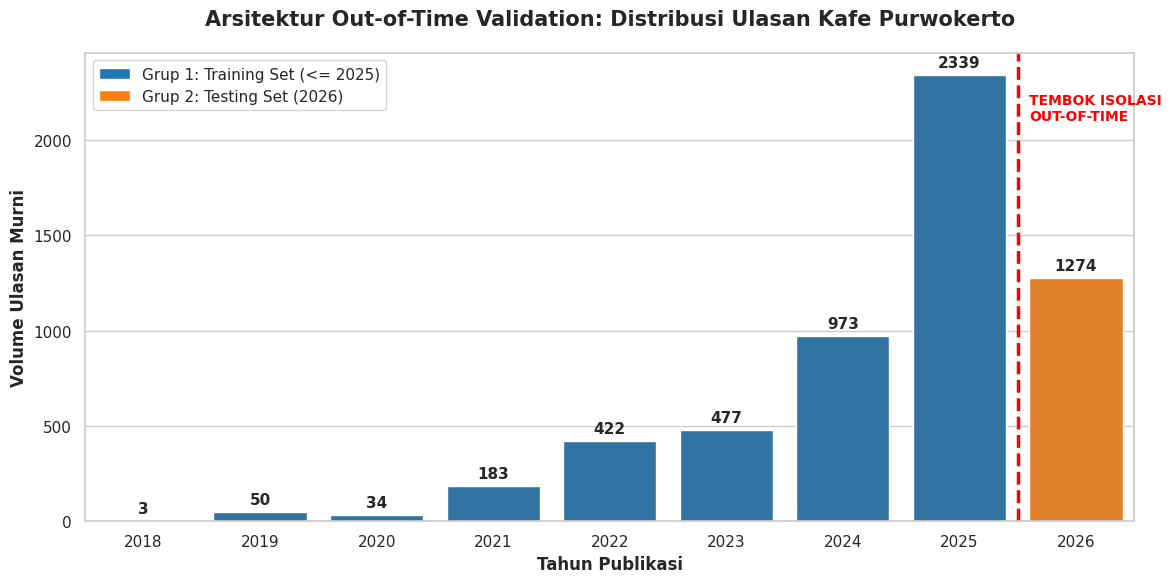

✅ Render grafik OOT selesai dengan parameter temporal yang akurat.


In [ ]:
# ============================================================
# CELL 7.5: Visualisasi Distribusi Temporal (OOT Validation)
# KOREKSI ARSITEKTUR: Sinkronisasi batas demarkasi ke tahun 2025
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

print("Merender Pemetaan Distribusi Temporal yang Telah Direvisi...")

# 1. Muat kembali data mentah
df_raw = pd.read_csv('Dataset_Kafe_Purwokerto_Raw.csv')
df_raw['waktu_ulasan'] = pd.to_datetime(df_raw['waktu_ulasan'], utc=True, errors='coerce')
df_raw = df_raw.dropna(subset=['waktu_ulasan'])
df_raw['tahun'] = df_raw['waktu_ulasan'].dt.year

# 2. Agregasi volume data per tahun
df_yearly = df_raw['tahun'].value_counts().sort_index().reset_index()
df_yearly.columns = ['Tahun', 'Volume']

# 3. Konfigurasi Kanvas Visual
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# KOREKSI LOGIKA: Biru untuk Latih (<=2025), Oranye untuk Uji (2026)
warna_kondisional = ['#1f77b4' if tahun <= 2025 else '#ff7f0e' for tahun in df_yearly['Tahun']]

ax = sns.barplot(data=df_yearly, x='Tahun', y='Volume', palette=warna_kondisional)

# 4. Injeksi Anotasi Numerik
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontweight='bold',
                fontsize=11)

# 5. Garis Demarkasi Isolasi Waktu
try:
    # KOREKSI TITIK POTONG: Geser ke tahun 2025
    titik_potong = df_yearly[df_yearly['Tahun'] == 2025].index[0]
    plt.axvline(x=titik_potong + 0.5, color='red', linestyle='--', linewidth=2.5)

    plt.text(titik_potong + 0.6, df_yearly['Volume'].max() * 0.9,
             'TEMBOK ISOLASI\nOUT-OF-TIME',
             color='red', fontweight='bold', fontsize=10)
except IndexError:
    pass

# 6. Elemen Tipografi & Legenda
plt.title('Arsitektur Out-of-Time Validation: Distribusi Ulasan Kafe Purwokerto',
          fontsize=15, fontweight='black', pad=20)
plt.xlabel('Tahun Publikasi', fontsize=12, fontweight='bold')
plt.ylabel('Volume Ulasan Murni', fontsize=12, fontweight='bold')

# KOREKSI LEGENDA
elemen_legenda = [
    Patch(facecolor='#1f77b4', label='Grup 1: Training Set (<= 2025)'),
    Patch(facecolor='#ff7f0e', label='Grup 2: Testing Set (2026)')
]
plt.legend(handles=elemen_legenda, loc='upper left', fontsize=11)

# 7. Ekspor Resolusi Tinggi
plt.tight_layout()
plt.savefig('Visualisasi_Distribusi_Temporal_Revisi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Render grafik OOT selesai dengan parameter temporal yang akurat.")

---
##  FASE II: HISTORICAL ENVIRONMENT EXPERIMENT

In [ ]:
# ============================================================
# CELL 8: Text Cleaning Blueprint (NLP Engine)
# Optimisasi: Perlindungan Kata Negasi & Penambalan Kamus Slang
# ============================================================
import re
import string
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

print("Mengompilasi NLP Engine Presisi Tinggi...")

# 1. Inisialisasi Sastrawi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 2. Inisialisasi NLTK Stopwords
daftar_stopword = set(stopwords.words('indonesian'))

# KUNCI ANALITIK: Lindungi kata negasi dan durasi agar tidak dihapus NLTK
kata_terlarang_dihapus = {'tidak', 'bukan', 'belum', 'jangan', 'kurang', 'lama'}
daftar_stopword = daftar_stopword - kata_terlarang_dihapus

# Tambahkan stopword kustom murni (noise)
stopword_tambahan = {'sih', 'nya', 'ya', 'deh', 'dong', 'kok', 'kan', 'nih', 'tuh', 'aja'}
daftar_stopword.update(stopword_tambahan)

# 3. Kamus Normalisasi Slang (Ditambal)
kamus_slang = {
    "yg": "yang", "bgt": "banget", "ga": "tidak", "gak": "tidak",
    "ngga": "tidak", "nggak": "tidak", "tp": "tapi", "dgn": "dengan",
    "udh": "sudah", "krn": "karena", "kalo": "kalau", "klo": "kalau",
    "trs": "terus", "jd": "jadi", "jgn": "jangan", "dr": "dari",
    "sy": "saya", "aq": "saya", "tmpt": "tempat", "bgs": "bagus",
    "kurg": "kurang", "d": "di", "dlm": "dalam", "lbh": "lebih",
    "cm": "cuma", "cmn": "cuma", "bnyk": "banyak", "mkn": "makan",
    "kopi": "kopi", "cafe": "kafe", "pake": "pakai", "bikin": "buat",
    # Penambalan bug hasil temuan tabel diagnostik:
    "jg": "juga", "pesen": "pesan", "dateng": "datang", "udah": "sudah"
}

# 4. Fungsi Utama Preprocessing
def bersihkan_teks(teks):
    if not isinstance(teks, str): return ""

    teks = teks.lower()

    # Cleansing
    teks = re.sub(r'http\S+|www\S+|https\S+', '', teks, flags=re.MULTILINE)
    teks = re.sub(r'\@\w+|\#', '', teks)
    teks = re.sub(r'\d+', '', teks)
    teks = teks.translate(str.maketrans('', '', string.punctuation))

    # Normalisasi Slang
    kata_kunci = teks.split()
    kata_terfilter = [kamus_slang.get(kata, kata) for kata in kata_kunci]

    # Filtering & Stemming
    teks_final = []
    for kata in kata_terfilter:
        if kata not in daftar_stopword and len(kata) > 2:
            kata_dasar = stemmer.stem(kata)
            if kata_dasar:
                teks_final.append(kata_dasar)

    return " ".join(teks_final)

print("✅ Blueprint NLP teroptimasi berhasil dimuat ke dalam memori.")

Mengompilasi NLP Engine Presisi Tinggi...
✅ Blueprint NLP teroptimasi berhasil dimuat ke dalam memori.


In [ ]:
# ============================================================
# CELL 8.5: Transformers Ingestion
# Mengunduh arsitektur Hugging Face untuk proses pelabelan teks murni
# ============================================================
import sys
print("Mengintegrasikan ekosistem Transformers...")
!{sys.executable} -m pip install -q transformers torch
print("✅ Ekosistem Transformers siap digunakan.")

In [ ]:
# ============================================================
# CELL 9: IndoBERT Text-Driven Labeling Pipeline (KOREKSI MODEL)
# Metode: Zero-Shot Knowledge Distillation (Teacher Model)
# Objektif: Membentuk Ground Truth otonom untuk data <= 2025
# ============================================================
import pandas as pd
from transformers import pipeline
import torch
from datetime import datetime

print(f"[{datetime.now().strftime('%H:%M:%S')}] Mengunduh Pre-trained IndoBERT Sentiment...")

# Identifier model alternatif yang stabil di direktori Hugging Face
nama_model = "mdhugol/indonesia-bert-sentiment-classification"

try:
    device_target = 0 if torch.cuda.is_available() else -1

    # Inisialisasi pipeline
    nlp_bert = pipeline(
        "sentiment-analysis",
        model=nama_model,
        device=device_target
    )

    print(f"[{datetime.now().strftime('%H:%M:%S')}] Memulai auto-labeling pada data latih...")

    # 1. Muat data latih historis awal (<= 2025)
    df_train = pd.read_csv('Dataset_Train_2025.csv')

    # 2. Bersihkan teks menggunakan fungsi bersihkan_teks (Cell 8 wajib sudah dieksekusi)
    df_train['teks_bersih'] = df_train['isi_ulasan'].apply(bersihkan_teks)
    df_train = df_train[df_train['teks_bersih'].str.strip() != '']
    df_train = df_train.dropna(subset=['teks_bersih'])

    # 3. Eksekusi prediksi teks melalui batch processing untuk manajemen RAM
    daftar_teks = df_train['teks_bersih'].tolist()
    hasil_bert = []
    ukuran_batch = 128

    for i in range(0, len(daftar_teks), ukuran_batch):
        batch = daftar_teks[i:i + ukuran_batch]
        hasil_batch = nlp_bert(batch, truncation=True, max_length=512)
        hasil_bert.extend(hasil_batch)
        print(f"  Proses batch {(i//ukuran_batch)+1} selesai...")

    # 4. Pemetaan label keluaran mdhugol (Prosa Dataset Mapping)
    peta_label = {
        'LABEL_0': 'positif',
        'LABEL_1': 'netral',
        'LABEL_2': 'negatif',
        'positive': 'positif',
        'neutral': 'netral',
        'negative': 'negatif'
    }

    labels_final = [peta_label.get(res['label'].lower(), res['label']) for res in hasil_bert]
    df_train['label_asli'] = labels_final

    # 5. Ekspor data latih final
    df_train.to_csv('Dataset_Train_2025_Clean.csv', index=False, encoding='utf-8-sig')

    print(f"\n[{datetime.now().strftime('%H:%M:%S')}] Proses pelabelan berbasis teks selesai!")
    print("\n📊 DISTRIBUSI SENTIMEN GROUND TRUTH (HASIL INDOBERT):")
    print(df_train['label_asli'].value_counts())
    print("\n✅ Berkas baru berhasil diekspor: 'Dataset_Train_2025_Clean.csv'")

except Exception as e:
    print(f"❌ Kegagalan saluran Transformers: {str(e)}")

In [ ]:
# ============================================================
# CELL 9.5: Diagnostic Table (Monitoring Pra-Pemrosesan Bertahap)
# KOREKSI: Pembaruan Sumber Data & Pemfilteran Leksikal Asing
# ============================================================
import pandas as pd
import re
import string

print("Menghasilkan Tabel Diagnostik Pemrosesan Bertahap...")

try:
    # 1. KOREKSI SUMBER: Gunakan dataset yang relevan secara arsitektur
    df_sample = pd.read_csv('Dataset_Train_2025.csv')

    # Filter ulasan agar cukup panjang untuk dianalisis
    df_sample = df_sample[df_sample['isi_ulasan'].str.split().str.len() > 10]

    # 2. FILTER BAHASA HEURISTIK SEDERHANA:
    # Hanya ambil ulasan yang mengandung minimal satu kata hubung umum bahasa Indonesia
    kata_kunci_id = ['dan', 'yang', 'di', 'ke', 'dari', 'pada', 'untuk']
    pola_id = r'\b(?:' + '|'.join(kata_kunci_id) + r')\b'
    df_sample = df_sample[df_sample['isi_ulasan'].str.lower().str.contains(pola_id, regex=True, na=False)]

    # Ambil 3 ulasan negatif/netral dan 2 ulasan positif
    sampel_neg = df_sample[df_sample['rating'] <= 3].head(3)
    sampel_pos = df_sample[df_sample['rating'] >= 4].head(2)
    df_diag = pd.concat([sampel_neg, sampel_pos]).reset_index(drop=True)

    # Inisialisasi list untuk setiap tahapan
    tahap_asli = df_diag['isi_ulasan'].tolist()
    tahap_casefolding = []
    tahap_cleansing = []
    tahap_normalisasi = []
    tahap_stopword = []
    tahap_stemming = []

    # 3. Eksekusi Bedah Bertahap
    for teks in tahap_asli:
        # Tahap 1: Case Folding
        t1 = str(teks).lower()
        tahap_casefolding.append(t1)

        # Tahap 2: Cleansing
        t2 = re.sub(r'http\S+|www\S+|https\S+', '', t1, flags=re.MULTILINE)
        t2 = re.sub(r'\@\w+|\#', '', t2)
        t2 = re.sub(r'\d+', '', t2)
        t2 = t2.translate(str.maketrans('', '', string.punctuation))
        tahap_cleansing.append(t2)

        # Tahap 3: Normalisasi (Translasi Slang)
        kata_t2 = t2.split()
        t3_list = [kamus_slang.get(kata, kata) for kata in kata_t2]
        t3 = " ".join(t3_list)
        tahap_normalisasi.append(t3)

        # Tahap 4: Stopword Removal
        t4_list = [kata for kata in t3_list if kata not in daftar_stopword]
        t4 = " ".join(t4_list)
        tahap_stopword.append(t4)

        # Tahap 5: Stemming Sastrawi
        t5_list = [stemmer.stem(kata) for kata in t4_list if len(kata) > 2]
        t5 = " ".join(t5_list)
        tahap_stemming.append(t5)

    # 4. Bangun DataFrame Presentasi
    df_monitoring = pd.DataFrame({
        'Teks Asli': tahap_asli,
        'Case Folding': tahap_casefolding,
        'Cleansing': tahap_cleansing,
        'Normalisasi': tahap_normalisasi,
        'Stopword': tahap_stopword,
        'Stemming (Final)': tahap_stemming
    })

    print("\n" + "="*80)
    print("🔍 TABEL MONITORING PRA-PEMROSESAN TEKS (SAMPEL)")
    print("="*80)
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_columns', None)
    display(df_monitoring)
    print("="*80)
    print("✅ Tabel diagnostik siap dipindahkan ke presentasi sidang.")

except Exception as e:
    print(f"❌ Kesalahan eksekusi: {e}")

Menghasilkan Tabel Diagnostik Pemrosesan Bertahap...

🔍 TABEL MONITORING PRA-PEMROSESAN TEKS (SAMPEL)


,Teks Asli,Case Folding,Cleansing,Normalisasi,Stopword,Stemming (Final)
0,Untuk Menu makan lumayan enak. Terutama nasgornya.. cm untuk minuman + steak gak. Minuman teralu upping price dgn tmpt lain yg lbh baik. Steak sgt alot. Klo compare dgn salah satu cafe mewah di baturaden. Massapi its a big no dr segi Harga,untuk menu makan lumayan enak. terutama nasgornya.. cm untuk minuman + steak gak. minuman teralu upping price dgn tmpt lain yg lbh baik. steak sgt alot. klo compare dgn salah satu cafe mewah di baturaden. massapi its a big no dr segi harga,untuk menu makan lumayan enak terutama nasgornya cm untuk minuman steak gak minuman teralu upping price dgn tmpt lain yg lbh baik steak sgt alot klo compare dgn salah satu cafe mewah di baturaden massapi its a big no dr segi harga,untuk menu makan lumayan enak terutama nasgornya cuma untuk minuman steak tidak minuman teralu upping price dengan tempat lain yang lebih baik steak sgt alot kalau compare dengan salah satu kafe mewah di baturaden massapi its a big no dari segi harga,menu makan lumayan enak nasgornya minuman steak tidak minuman teralu upping price steak sgt alot compare salah kafe mewah baturaden massapi its a big no segi harga,menu makan lumayan enak nasgornya minum steak tidak minum alu upping price steak sgt alot compare salah kafe mewah baturaden massapi its big segi harga
1,"malem harii ke massapii untuk nasi gorengnyaa enak sop massapi enak juga, tetapi untukk MENDOANNYA not recommended sering ke massapi kalo malem pesen MENDOAN pasti mendoanya kalo ga SANGIT adonannya COKLAT kaya adonan lama ga niat goreng mending MENDOAN pinggir jalan warnanya bagus enakk ga sangit","malem harii ke massapii untuk nasi gorengnyaa enak sop massapi enak juga, tetapi untukk mendoannya not recommended sering ke massapi kalo malem pesen mendoan pasti mendoanya kalo ga sangit adonannya coklat kaya adonan lama ga niat goreng mending mendoan pinggir jalan warnanya bagus enakk ga sangit",malem harii ke massapii untuk nasi gorengnyaa enak sop massapi enak juga tetapi untukk mendoannya not recommended sering ke massapi kalo malem pesen mendoan pasti mendoanya kalo ga sangit adonannya coklat kaya adonan lama ga niat goreng mending mendoan pinggir jalan warnanya bagus enakk ga sangit,malem harii ke massapii untuk nasi gorengnyaa enak sop massapi enak juga tetapi untukk mendoannya not recommended sering ke massapi kalau malem pesan mendoan pasti mendoanya kalau tidak sangit adonannya coklat kaya adonan lama tidak niat goreng mending mendoan pinggir jalan warnanya bagus enakk tidak sangit,malem harii massapii nasi gorengnyaa enak sop massapi enak untukk mendoannya not recommended massapi malem pesan mendoan mendoanya tidak sangit adonannya coklat kaya adonan lama tidak niat goreng mending mendoan pinggir jalan warnanya bagus enakk tidak sangit,malem hari massapii nasi gorengnyaa enak sop massapi enak untukk mendoan not recommended massapi malem pesan mendoan doa tidak sangit adon coklat kaya adon lama tidak niat goreng mending mendoan pinggir jalan warna bagus enakk tidak sangit
2,"milkshake avocado nya pait bgt Cok di blender sekulit kulite kayane , untuk tempat better lah, cuma PAIT BANGET COK","milkshake avocado nya pait bgt cok di blender sekulit kulite kayane , untuk tempat better lah, cuma pait banget cok",milkshake avocado nya pait bgt cok di blender sekulit kulite kayane untuk tempat better lah cuma pait banget cok,milkshake avocado nya pait banget cok di blender sekulit kulite kayane untuk tempat better lah cuma pait banget cok,milkshake avocado pait banget cok blender sekulit kulite kayane better pait banget cok,milkshake avocado pait banget cok blender kulit kulite kayane better pait banget cok
3,"Semua makanan enak bangett, pelayanannya ramah banget , kakak kakaknya cantik dan gantengg bangett, minumannya enakk, platingannya cantik dan menarik banget, tempatnya nyaman dan sejuk, viewnya langsung ke gunung matahari.","semua makanan enak bangett, pelayanannya ramah banget , kakak kakaknya

✅ Tabel diagnostik siap dipindahkan ke presentasi sidang.


In [ ]:
# ============================================================
# CELL 10: Label Format Patching
# ============================================================
import pandas as pd

df_patch = pd.read_csv('Dataset_Train_2025_Clean.csv')
pemetaan_koreksi = {'LABEL_0': 'positif', 'LABEL_1': 'netral', 'LABEL_2': 'negatif'}
df_patch['label_asli'] = df_patch['label_asli'].map(pemetaan_koreksi).fillna(df_patch['label_asli'])

print("Distribusi Sentimen Terkoreksi:")
print(df_patch['label_asli'].value_counts())
df_patch.to_csv('Dataset_Train_2025_Clean.csv', index=False, encoding='utf-8-sig')

Distribusi Sentimen Terkoreksi:
label_asli
positif    3864
negatif     435
netral      169
Name: count, dtype: int64


In [ ]:
# ============================================================
# CELL 11: Feature Space Extraction (TF-IDF)
# Objektif: Mengubah teks bersih menjadi matriks probabilitas numerik
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

print("Mengekstrak fitur ruang vektor dari teks murni...")

df_train = pd.read_csv('Dataset_Train_2025_Clean.csv')

# Inisialisasi TF-IDF dengan parameter N-Gram (Unigram & Bigram)
# Membantu menangkap konteks gabungan kata seperti "tidak enak"
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

X_tekstual = df_train['teks_bersih']
y_target = df_train['label_asli']

# Fit dan Transform HANYA pada data latih untuk mencegah Data Leakage
X_vektor = vectorizer.fit_transform(X_tekstual)

# Simpan objek vectorizer ke penyimpanan lokal untuk dipakai di Fase III (Data 2026)
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

print(f"✅ Ekstraksi selesai. Dimensi matriks fitur: {X_vektor.shape}")
print("Objek TF-IDF telah diamankan dalam 'tfidf_vectorizer.pkl'.")

Mengekstrak fitur ruang vektor dari teks murni...
✅ Ekstraksi selesai. Dimensi matriks fitur: (4468, 5000)
Objek TF-IDF telah diamankan dalam 'tfidf_vectorizer.pkl'.


In [ ]:
# ============================================================
# CELL 12: Controlled Undersampling Balancing
# Objektif: Menyamaratakan kelas sentimen sesuai instruksi dosen
# ============================================================
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("Mengeksekusi pemotongan data (Random Undersampling)...")

# Inisialisasi RandomUnderSampler
# random_state dikunci pada angka 42 agar hasil sidang dapat direproduksi ulang
rus = RandomUnderSampler(random_state=42)

X_vektor_seimbang, y_target_seimbang = rus.fit_resample(X_vektor, y_target)

print("📊 PERBANDINGAN DISTRIBUSI KELAS (SEBELUM VS SESUDAH):")
print(f"Sebelum Undersampling : {Counter(y_target)}")
print(f"Sesudah Undersampling : {Counter(y_target_seimbang)}")
print(f"Dimensi matriks final : {X_vektor_seimbang.shape}")
print("\n✅ Dataset kini seimbang secara absolut.")

Mengeksekusi pemotongan data (Random Undersampling)...
📊 PERBANDINGAN DISTRIBUSI KELAS (SEBELUM VS SESUDAH):
Sebelum Undersampling : Counter({'positif': 3864, 'negatif': 435, 'netral': 169})
Sesudah Undersampling : Counter({'negatif': 169, 'netral': 169, 'positif': 169})
Dimensi matriks final : (507, 5000)

✅ Dataset kini seimbang secara absolut.


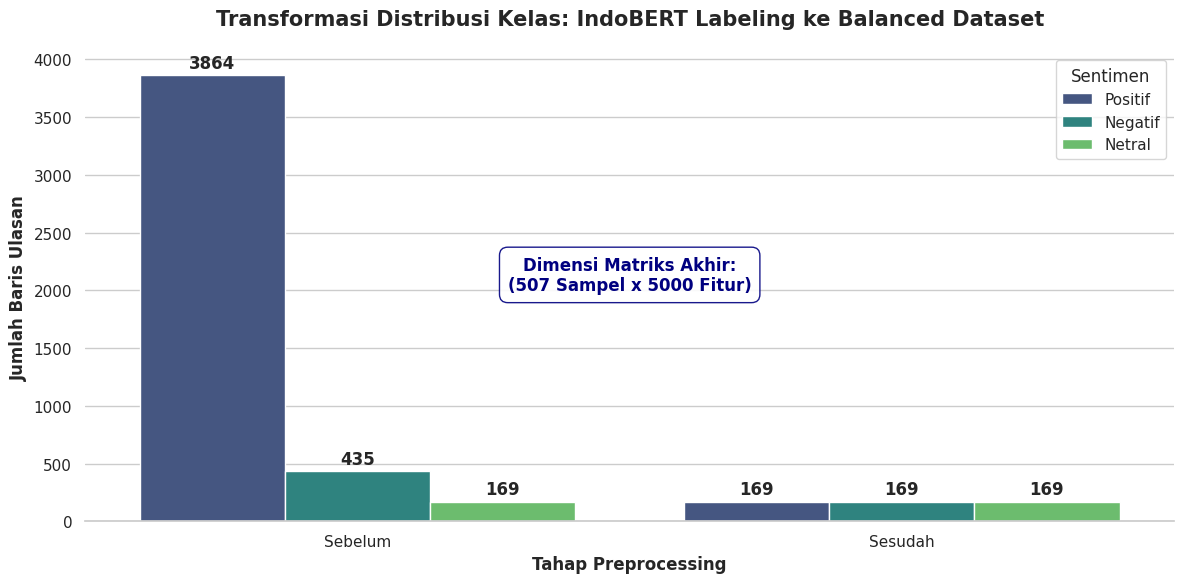

✅ Visualisasi terkoreksi berhasil diekspor sebagai 'Transformasi_Data_UnderSampling_Fixed.png'.


In [ ]:
# ============================================================
# CELL 12.5 (PATCHED): Visualisasi Transformasi Distribusi Data
# Koreksi: Sinkronisasi Hue, Penghapusan Bar Kosong, & Posisi Kotak
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data murni tanpa modifikasi spasi
data_dist = {
    'Kelas': ['Positif', 'Negatif', 'Netral', 'Positif', 'Negatif', 'Netral'],
    'Jumlah': [3864, 435, 169, 169, 169, 169],
    'Tahap': ['Sebelum', 'Sebelum', 'Sebelum', 'Sesudah', 'Sesudah', 'Sesudah']
}

df_plot = pd.DataFrame(data_dist)

# Mengunci urutan sumbu X agar 'Sebelum' selalu di kiri
df_plot['Tahap'] = pd.Categorical(df_plot['Tahap'], categories=['Sebelum', 'Sesudah'], ordered=True)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot Utama
ax = sns.barplot(x='Tahap', y='Jumlah', hue='Kelas', data=df_plot, palette='viridis')

# Anotasi angka yang hanya mengeksekusi bar dengan nilai > 0
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, '.0f'),
                       (p.get_x() + p.get_width() / 2., height),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points',
                       fontweight='bold', fontsize=12)

plt.title('Transformasi Distribusi Kelas: IndoBERT Labeling ke Balanced Dataset', fontsize=15, fontweight='black', pad=20)
plt.xlabel('Tahap Preprocessing', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Baris Ulasan', fontsize=12, fontweight='bold')
plt.legend(title='Sentimen', loc='upper right', fontsize=11, title_fontsize=12)

# Reposisi kotak dimensi agar lebih sentral dan proporsional
plt.text(0.5, 2000, f'Dimensi Matriks Akhir:\n(507 Sampel x 5000 Fitur)',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='navy', boxstyle='round,pad=0.5'),
         fontsize=12, fontweight='bold', ha='center', color='navy')

sns.despine(left=True)
plt.tight_layout()
nama_file = 'Transformasi_Data_UnderSampling_Fixed.png'
plt.savefig(nama_file, dpi=300)
plt.show()

print(f"✅ Visualisasi terkoreksi berhasil diekspor sebagai '{nama_file}'.")

Mengeksekusi Benchmark Algoritma & Visualisasi Matriks Kebingungan...
Sedang menala hyperparameter untuk Logistic Reg...
Sedang menala hyperparameter untuk Linear SVC...
Sedang menala hyperparameter untuk Complement NB...
Sedang menala hyperparameter untuk Random Forest...

🏆 TABEL PERBANDINGAN MODEL HASIL HYPERPARAMETER TUNING


,Model,Val F1-Macro,Parameter Terbaik,Waktu (s)
0,Logistic Reg,0.7292,"{'C': 0.1, 'solver': 'liblinear'}",5.01
1,Linear SVC,0.7261,"{'C': 0.1, 'loss': 'squared_hinge'}",0.30
3,Random Forest,0.7056,"{'max_depth': 50, 'n_estimators': 200}",25.93
2,Complement NB,0.6856,"{'alpha': 2.0, 'norm': True}",0.19


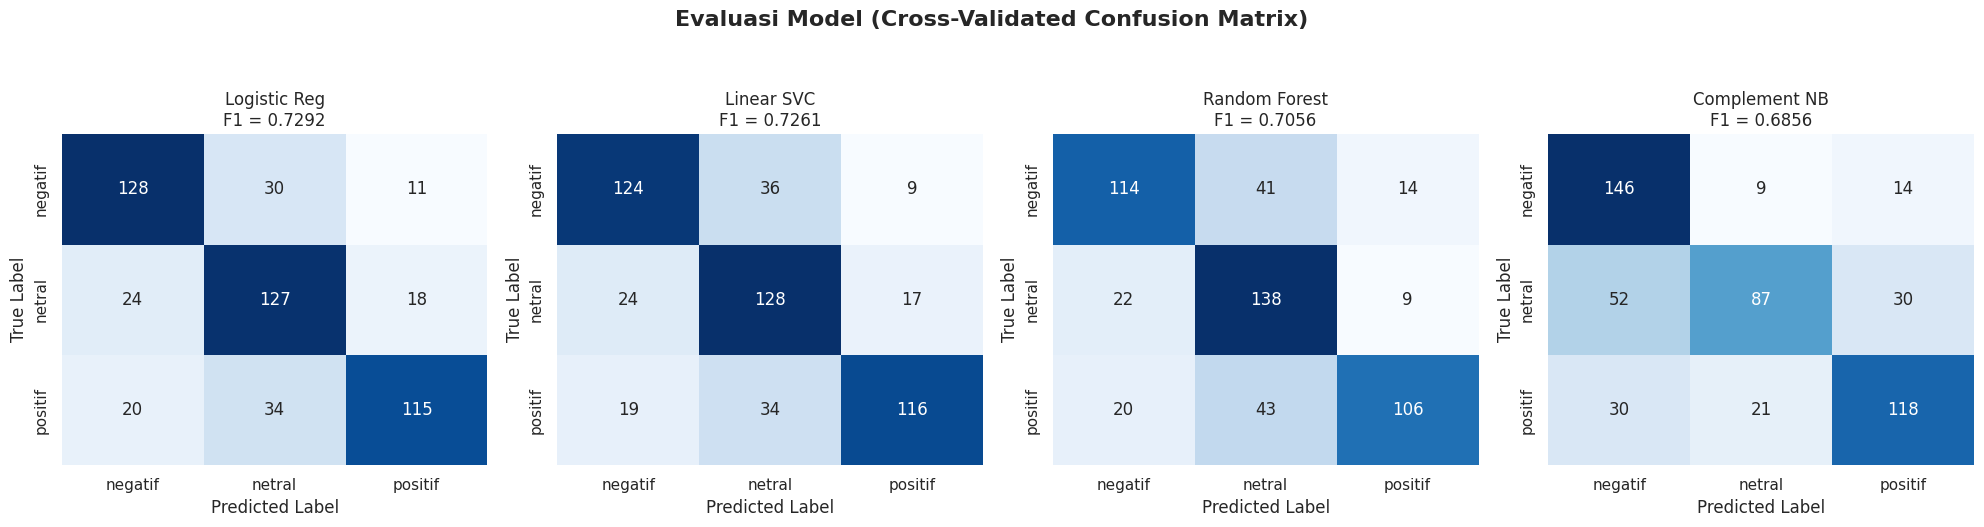

✅ Pengujian selesai. Matriks komparasi dan visualisasi telah dirender.


In [ ]:
# ============================================================
# CELL 13: The Ultimate Gladiator Arena
# Hyperparameter Tuning + Cross-Val Confusion Matrix Visualization
# ============================================================
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Mengeksekusi Benchmark Algoritma & Visualisasi Matriks Kebingungan...")

# 1. Konfigurasi Ruang Pencarian Hyperparameter (Termasuk Random Forest)
ruang_parameter = {
    'Logistic Reg': {
        'model': LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'),
        'params': {'C': [0.1, 1.0, 10.0], 'solver': ['liblinear', 'lbfgs']}
    },
    'Linear SVC': {
        'model': LinearSVC(random_state=42, max_iter=3000, class_weight='balanced'),
        'params': {'C': [0.1, 1.0, 10.0], 'loss': ['hinge', 'squared_hinge']}
    },
    'Complement NB': {
        'model': ComplementNB(),
        'params': {'alpha': [0.1, 1.0, 2.0], 'norm': [True, False]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'params': {'n_estimators': [100, 200], 'max_depth': [None, 50]}
    }
}

skema_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
hasil_komparasi = []
koleksi_model_terbaik = {}
prediksi_cv_gabungan = {} # Untuk menyimpan hasil prediksi out-of-fold

# 2. Eksekusi Grid Search & Pengumpulan Prediksi
for nama, konfigurasi in ruang_parameter.items():
    waktu_mulai = time.time()
    print(f"Sedang menala hyperparameter untuk {nama}...")

    grid_search = GridSearchCV(
        estimator=konfigurasi['model'],
        param_grid=konfigurasi['params'],
        cv=skema_cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    # Latih untuk mencari parameter terbaik
    grid_search.fit(X_vektor_seimbang, y_target_seimbang)
    model_terbaik = grid_search.best_estimator_
    koleksi_model_terbaik[nama] = model_terbaik

    # Lakukan cross_val_predict untuk Confusion Matrix
    y_pred_cv = cross_val_predict(model_terbaik, X_vektor_seimbang, y_target_seimbang, cv=skema_cv)
    prediksi_cv_gabungan[nama] = y_pred_cv

    waktu_selesai = time.time()

    hasil_komparasi.append({
        'Model': nama,
        'Val F1-Macro': grid_search.best_score_,
        'Parameter Terbaik': str(grid_search.best_params_),
        'Waktu (s)': round(waktu_selesai - waktu_mulai, 2)
    })

# 3. Cetak Tabel Komparasi Peringkat
df_komparasi = pd.DataFrame(hasil_komparasi).sort_values(by='Val F1-Macro', ascending=False)
df_komparasi['Val F1-Macro'] = df_komparasi['Val F1-Macro'].round(4)

print("\n" + "="*80)
print("🏆 TABEL PERBANDINGAN MODEL HASIL HYPERPARAMETER TUNING")
print("="*80)
display(df_komparasi)

# 4. Render Visualisasi Confusion Matrix Berdampingan
urutan_model = df_komparasi['Model'].tolist()
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Evaluasi Model (Cross-Validated Confusion Matrix)', fontsize=16, fontweight='bold', y=1.05)

label_kelas = ['negatif', 'netral', 'positif']

for idx, nama_model in enumerate(urutan_model):
    ax = axes[idx]
    y_pred_aktual = prediksi_cv_gabungan[nama_model]
    cm = confusion_matrix(y_target_seimbang, y_pred_aktual, labels=label_kelas)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=label_kelas, yticklabels=label_kelas)

    # Ambil skor F1 dari dataframe untuk judul subplot
    skor_f1 = df_komparasi[df_komparasi['Model'] == nama_model]['Val F1-Macro'].values[0]
    ax.set_title(f"{nama_model}\nF1 = {skor_f1:.4f}", fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('Confusion_Matrix_Komparasi.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Pengujian selesai. Matriks komparasi dan visualisasi telah dirender.")

In [ ]:
# ============================================================
# CELL 14: Pemenang Arena & Kompilasi Model Final (Patched)
# Objektif: Mengekstraksi model terbaik hasil tuning untuk produksi
# ============================================================
import pickle

# 1. Ekstrak nama model terbaik dari dataframe komparasi (indeks teratas)
nama_pemenang = df_komparasi.iloc[0]['Model']
skor_pemenang = df_komparasi.iloc[0]['Val F1-Macro']

print(f"Model Pemenang Terpilih : {nama_pemenang}")
print(f"Skor Val F1-Macro       : {skor_pemenang:.4f}")
print(f"Konfigurasi Parameter   : {df_komparasi.iloc[0]['Parameter Terbaik']}")

# 2. Ambil objek estimator yang sudah memiliki parameter optimal dari dictionary sebelumnya
model_terbaik = koleksi_model_terbaik[nama_pemenang]

# 3. Latih ulang menggunakan seluruh data latih (507 baris) untuk memadatkan pemahaman
print("\nMelatih ulang model pemenang menggunakan seluruh data latih seimbang...")
model_terbaik.fit(X_vektor_seimbang, y_target_seimbang)

# 4. Amankan model ke penyimpanan lokal untuk dipakai di Fase III
with open('model_sentimen_terbaik.pkl', 'wb') as file:
    pickle.dump(model_terbaik, file)

print("\nSistem klasifikasi terkunci mutlak.")
print("Model pemenang berhasil diamankan dalam 'model_sentimen_terbaik.pkl'.")
print("Tahap historis (<= 2025) resmi ditutup.")

Model Pemenang Terpilih : Logistic Reg
Skor Val F1-Macro       : 0.7292
Konfigurasi Parameter   : {'C': 0.1, 'solver': 'liblinear'}

Melatih ulang model pemenang menggunakan seluruh data latih seimbang...

Sistem klasifikasi terkunci mutlak.
Model pemenang berhasil diamankan dalam 'model_sentimen_terbaik.pkl'.
Tahap historis (<= 2025) resmi ditutup.


---
##  FASE III: LIVE PRODUCTION & PREDICTION ENVIRONMENT (DATA 2025–2026)

In [ ]:
# ============================================================
# CELL 15: Production Preprocessing Execution (Lingkungan 2026)
# Objektif: Membersihkan data masa depan tanpa mengubah parameter historis
# ============================================================
import pandas as pd
from datetime import datetime

print(f"[{datetime.now().strftime('%H:%M:%S')}] Membuka gerbang data Out-of-Time (Tahun 2026)...")

# 1. Muat dataset murni tahun 2026
df_test_2026 = pd.read_csv('Dataset_Test_2026.csv')
total_awal = len(df_test_2026)

print(f"Total ulasan mentah 2026: {total_awal} baris.")
print("Mengaplikasikan NLP Text Cleaning...")

# 2. Bersihkan teks menggunakan Blueprint Cell 8
# Peringatan: Jangan pernah menghapus ulasan berdasarkan rating di fase ini.
# Biarkan model AI yang menilainya murni dari teks.
df_test_2026['teks_bersih'] = df_test_2026['isi_ulasan'].apply(bersihkan_teks)

# 3. Filter teks kosong akibat pembersihan
df_test_2026 = df_test_2026[df_test_2026['teks_bersih'].str.strip() != '']
df_test_2026 = df_test_2026.dropna(subset=['teks_bersih'])

print(f"[{datetime.now().strftime('%H:%M:%S')}] Pra-pemrosesan 2026 selesai. Sisa data valid: {len(df_test_2026)} baris.")

[02:39:53] Membuka gerbang data Out-of-Time (Tahun 2026)...
Total ulasan mentah 2026: 1274 baris.
Mengaplikasikan NLP Text Cleaning...
[02:46:02] Pra-pemrosesan 2026 selesai. Sisa data valid: 1272 baris.


In [ ]:
# ============================================================
# CELL 16 & 17: Future Vectorization & AI Live Label Prediction
# Objektif: Memprediksi sentimen ulasan 2026 secara otonom
# ============================================================
import pickle

print("Memuat matriks TF-IDF dan model Logistic Regression historis...")

# 1. Muat objek yang telah dilatih dari Fase II
with open('tfidf_vectorizer.pkl', 'rb') as file:
    vectorizer_produksi = pickle.load(file)

with open('model_sentimen_terbaik.pkl', 'rb') as file:
    model_produksi = pickle.load(file)

# 2. Transformasi Vektor (KUNCI: Gunakan .transform, BUKAN .fit_transform)
print("Mengubah teks 2026 ke dalam representasi numerik historis...")
X_produksi = vectorizer_produksi.transform(df_test_2026['teks_bersih'])

# 3. Eksekusi Prediksi AI Otonom
print("Logistic Regression sedang mengevaluasi sentimen...")
prediksi_sentimen = model_produksi.predict(X_produksi)

# 4. Injeksi hasil prediksi ke dalam dataframe
df_test_2026['prediksi_ai'] = prediksi_sentimen

# 5. Ekspor data produksi yang telah dilabeli AI
nama_file_produksi = 'Dataset_Production_2026_Predicted.csv'
df_test_2026.to_csv(nama_file_produksi, index=False, encoding='utf-8-sig')

print("\n" + "="*50)
print("📊 DISTRIBUSI SENTIMEN 2026 (HASIL PREDIKSI LOGISTIC REGRESSION):")
print("="*50)
print(df_test_2026['prediksi_ai'].value_counts())
print("="*50)
print(f"✅ Prediksi buta berhasil. Data siap divisualisasikan di Fase IV: {nama_file_produksi}")

Memuat matriks TF-IDF dan model Logistic Regression historis...
Mengubah teks 2026 ke dalam representasi numerik historis...
Logistic Regression sedang mengevaluasi sentimen...

📊 DISTRIBUSI SENTIMEN 2026 (HASIL PREDIKSI LOGISTIC REGRESSION):
prediksi_ai
positif    742
netral     271
negatif    259
Name: count, dtype: int64
✅ Prediksi buta berhasil. Data siap divisualisasikan di Fase IV: Dataset_Production_2026_Predicted.csv


Merender ulang aset visual presentasi dengan presisi...


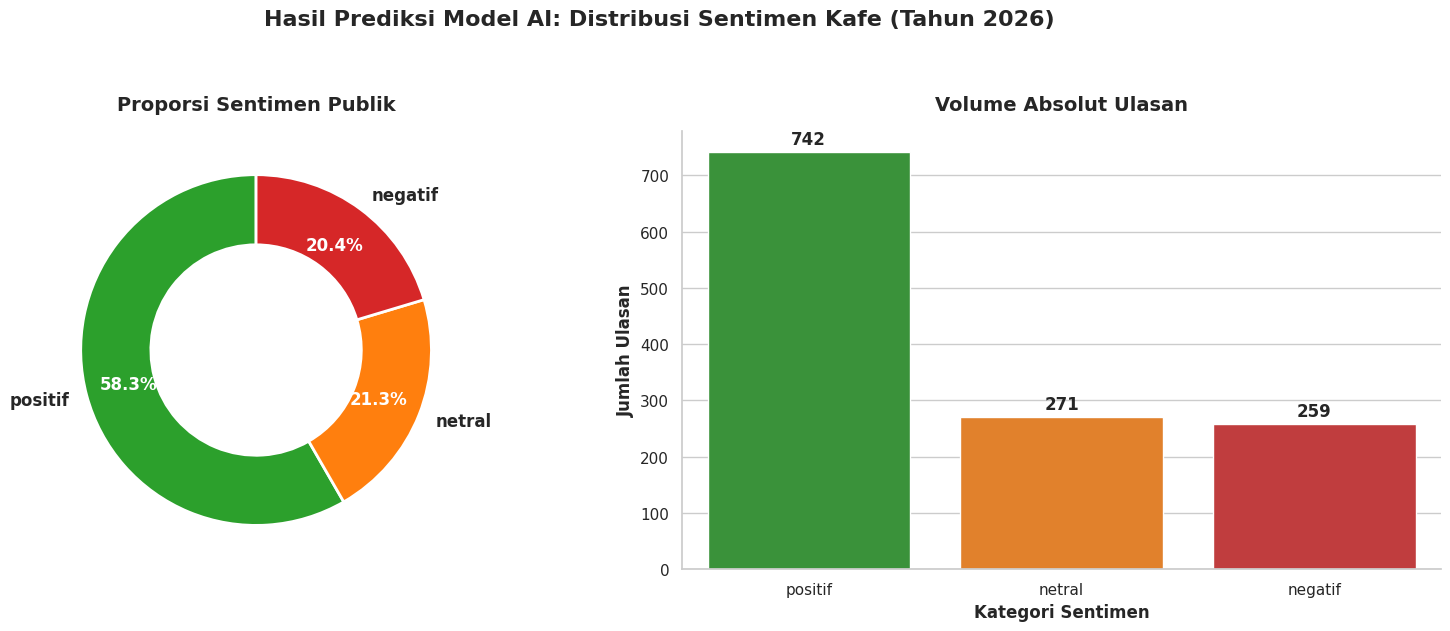

✅ Render visual selesai. Grafik disimpan sebagai: Visualisasi_Prediksi_2026_Fixed.png


In [ ]:
# ============================================================
# CELL 17.5: Visualisasi Produksi Out-of-Time 2026 (PATCHED)
# Objektif: Memperbaiki tata letak teks persentase pada Donut Chart
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("Merender ulang aset visual presentasi dengan presisi...")

distribusi_2026 = df_test_2026['prediksi_ai'].value_counts()
label_kelas = distribusi_2026.index
nilai_kelas = distribusi_2026.values

warna_sentimen = {'positif': '#2ca02c', 'netral': '#ff7f0e', 'negatif': '#d62728'}
palet_warna = [warna_sentimen[label] for label in label_kelas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hasil Prediksi Model AI: Distribusi Sentimen Kafe (Tahun 2026)',
             fontsize=16, fontweight='black', y=1.05)

# --- VISUALISASI 1: Donut Chart (KOREKSI RADIUS TEKS) ---
# Menambahkan parameter pctdistance=0.75 untuk menarik teks ke tengah irisan
wedges, texts, autotexts = ax1.pie(nilai_kelas, labels=label_kelas,
                                   autopct='%1.1f%%', startangle=90,
                                   colors=palet_warna, pctdistance=0.75,
                                   wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
                                   textprops={'fontsize': 12, 'fontweight': 'bold'})

ax1.set_title('Proporsi Sentimen Publik', fontsize=14, fontweight='bold', pad=15)

for autotext in autotexts:
    autotext.set_color('white')

# --- VISUALISASI 2: Bar Chart ---
sns.barplot(x=label_kelas, y=nilai_kelas, palette=palet_warna, ax=ax2)
ax2.set_title('Volume Absolut Ulasan', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Jumlah Ulasan', fontsize=12, fontweight='bold')
ax2.set_xlabel('Kategori Sentimen', fontsize=12, fontweight='bold')

for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.0f'),
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 9), textcoords='offset points',
                 fontweight='bold', fontsize=12)

sns.despine(ax=ax2)

nama_file_visual = 'Visualisasi_Prediksi_2026_Fixed.png'
plt.tight_layout()
plt.savefig(nama_file_visual, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Render visual selesai. Grafik disimpan sebagai: {nama_file_visual}")

---
##  FASE IV: DOWNSTREAM ANALYTICS & SPATIAL DASHBOARD

In [ ]:
# ============================================================
# CELL 18: Structural Topic Modeling (LDA)
# Objektif: Mengekstrak kluster masalah utama dari ulasan negatif tahun 2026
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

print("Mengeksekusi Structural Topic Modeling (LDA) pada keluhan konsumen...")

# Filter khusus ulasan yang diprediksi negatif oleh model Logistic Regression di tahun 2026
df_negatif_2026 = df_test_2026[df_test_2026['prediksi_ai'] == 'negatif']

if not df_negatif_2026.empty:
    # 1. Ekstraksi matriks frekuensi kata (Bag of Words)
    # Menggunakan unigram dan bigram untuk menangkap konteks frasa
    tf_vectorizer = CountVectorizer(max_features=1000, ngram_range=(1, 2))
    tf_matriks = tf_vectorizer.fit_transform(df_negatif_2026['teks_bersih'])

    # 2. Inisialisasi LDA dengan 3 komponen topik utama
    lda_model = LatentDirichletAllocation(n_components=3, random_state=42)
    lda_model.fit(tf_matriks)

    # 3. Tampilkan kata kunci dominan per kluster topik
    kata_kunci = tf_vectorizer.get_feature_names_out()
    print("\nHASIL EKSTRAKSI TOPIK KELUHAN (DOWNSTREAM ANALYTICS):")

    for idx, topik in enumerate(lda_model.components_):
        indeks_kata_teratas = topik.argsort()[:-11:-1]
        top_words = [kata_kunci[i] for i in indeks_kata_teratas]
        print(f"\n📌 Kelompok Masalah {idx + 1}:")
        print(", ".join(top_words))
else:
    print("⚠ Abort: Tidak ditemukan data ulasan negatif tahun 2026 untuk pemodelan topik.")

Mengeksekusi Structural Topic Modeling (LDA) pada keluhan konsumen...

HASIL EKSTRAKSI TOPIK KELUHAN (DOWNSTREAM ANALYTICS):

📌 Kelompok Masalah 1:
tidak, makan, banget, enak, harga, layan, kopi, minum, kasir, beli

📌 Kelompok Masalah 2:
tidak, layan, banget, pesan, makan, parkir, menu, lama, nunggu, oke

📌 Kelompok Masalah 3:
tidak, layan, makan, ramah, jam, lama, banget, pesan, kurang, pas


Merender Komparasi Distribusi Sentimen Antar Kawasan...


<Figure size 1200x600 with 0 Axes>

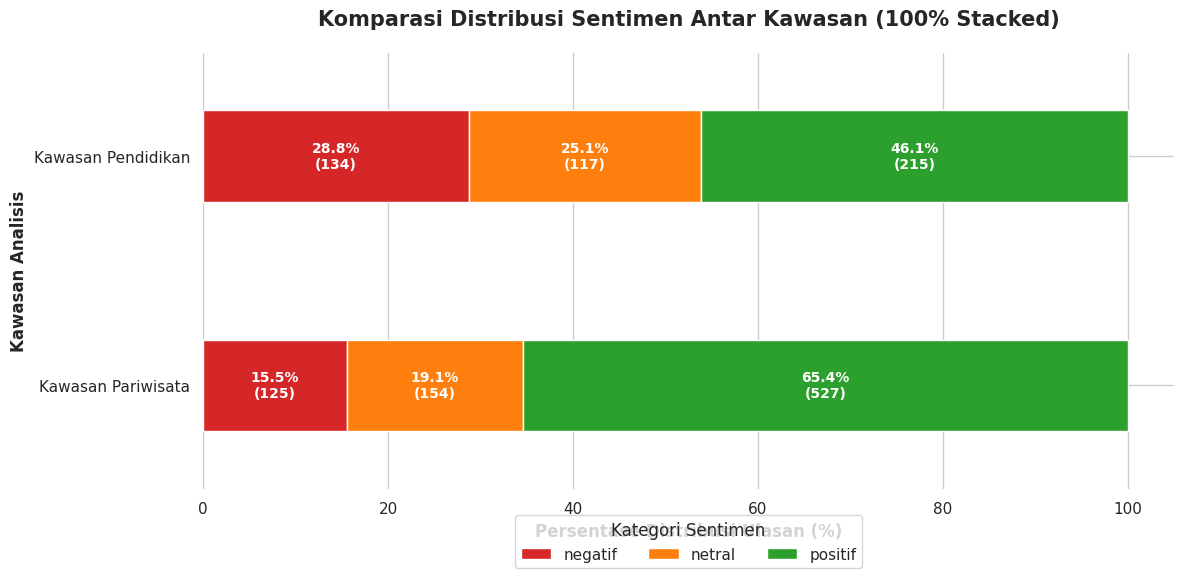

✅ Grafik regional berhasil diekspor sebagai 'Komparasi_Sentimen_Regional_2026.png'.


In [ ]:
# ============================================================
# CELL 19: Comparative Regional Visualization (100% Stacked)
# Objektif: Render grafik batang bertumpuk persentase dan frekuensi absolut
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Merender Komparasi Distribusi Sentimen Antar Kawasan...")

# 1. Membuat tabel kontingensi silang (Kawasan vs Hasil Prediksi AI)
tabel_kontingensi = pd.crosstab(df_test_2026['kawasan'], df_test_2026['prediksi_ai'])

# Memastikan urutan kolom dari kiri ke kanan secara psikologis visual: negatif, netral, positif
kolom_urut = [k for k in ['negatif', 'netral', 'positif'] if k in tabel_kontingensi.columns]
tabel_kontingensi = tabel_kontingensi[kolom_urut]

# Konversi data absolut menjadi persentase kumulatif 100%
tabel_persen = tabel_kontingensi.div(tabel_kontingensi.sum(axis=1), axis=0) * 100

# 2. Setup Konfigurasi Kanvas
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
warna_sentimen = ['#d62728', '#ff7f0e', '#2ca02c'] # Merah (Negatif), Oranye (Netral), Hijau (Positif)

# Plot grafik horizontal bertumpuk
ax = tabel_persen.plot(kind='barh', stacked=True, color=warna_sentimen, figsize=(12, 6), width=0.4)

# 3. Injeksi Teks Angka Absolut dan Persentase Tepat di Dalam Segmen Batang
for i in range(len(tabel_kontingensi)):
    akumulasi_x = 0
    for col_idx, kolom in enumerate(kolom_urut):
        nilai_persen = tabel_persen.loc[tabel_persen.index[i], kolom]
        nilai_absolut = tabel_kontingensi.loc[tabel_kontingensi.index[i], kolom]

        if nilai_persen > 4: # Hanya cetak label jika segmen cukup besar agar tidak tumpang tindih
            posisi_x = akumulasi_x + (nilai_persen / 2)
            ax.text(posisi_x, i, f"{nilai_persen:.1f}%\n({nilai_absolut})",
                    ha='center', va='center', color='white',
                    fontweight='bold', fontsize=10)
        akumulasi_x += nilai_persen

# 4. Sentuhan Akhir Tipografi Poster
plt.title('Komparasi Distribusi Sentimen Antar Kawasan (100% Stacked)', fontsize=15, fontweight='black', pad=20)
plt.xlabel('Persentase Distribusi Ulasan (%)', fontsize=12, fontweight='bold')
plt.ylabel('Kawasan Analisis', fontsize=12, fontweight='bold')
plt.xlim(0, 105)
plt.legend(title='Kategori Sentimen', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=11)

# Bersihkan garis tepi grafik
sns.despine(left=True, bottom=True)
plt.tight_layout()

# Ekspor grafik dengan resolusi cetak poster
nama_file_regional = 'Komparasi_Sentimen_Regional_2026.png'
plt.savefig(nama_file_regional, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Grafik regional berhasil diekspor sebagai '{nama_file_regional}'.")

Mengeksekusi ulang ekstraksi Bigram Negatif...


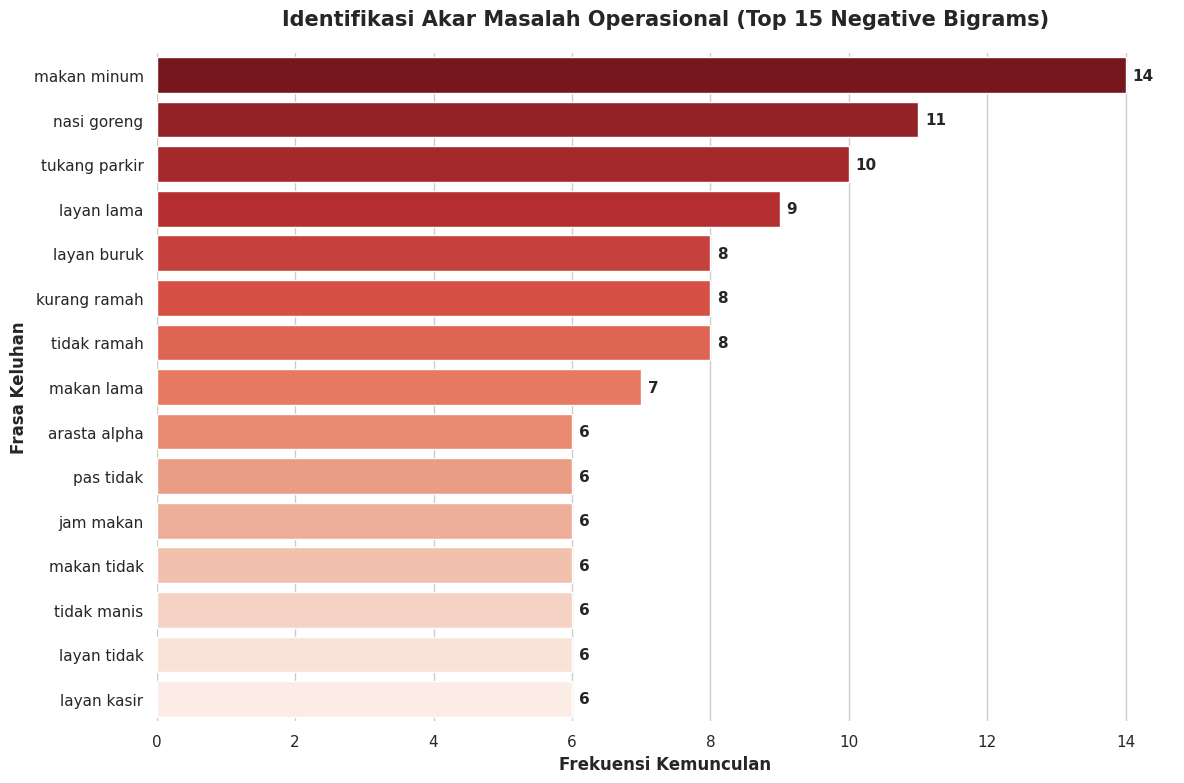

✅ Filter leksikal terkoreksi. Grafik diekspor sebagai 'Akar_Masalah_Operasional_2026_Fixed.png'.


In [ ]:
# ============================================================
# CELL 20: Domain Vocabulary Filtering (PATCHED)
# Koreksi: Mempertahankan Negasi & Memfilter Sentimen Campuran
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

print("Mengeksekusi ulang ekstraksi Bigram Negatif...")

df_negatif_2026 = df_test_2026[df_test_2026['prediksi_ai'] == 'negatif']

if not df_negatif_2026.empty:
    # 1. KOREKSI STOPWORD: 'tidak' dan 'kurang' DIHAPUS dari list ini agar tetap hidup
    stopword_domain = ['banget', 'sangat', 'paling', 'cuma', 'hanya', 'yang',
                       'dan', 'di', 'ke', 'dari', 'buat', 'ada', 'kalau', 'kalo',
                       'sama', 'juga', 'udah', 'sudah', 'sih', 'nya', 'aja', 'tapi']

    # 2. Inisialisasi Vectorizer
    vectorizer_bigram = CountVectorizer(ngram_range=(2, 2), stop_words=stopword_domain)

    try:
        matriks_bigram = vectorizer_bigram.fit_transform(df_negatif_2026['teks_bersih'])
        jumlah_frasa = matriks_bigram.sum(axis=0)
        frasa_keluhan = [(kata, jumlah_frasa[0, idx]) for kata, idx in vectorizer_bigram.vocabulary_.items()]

        df_frasa = pd.DataFrame(frasa_keluhan, columns=['Frasa Masalah', 'Frekuensi'])

        # 3. FILTER SENTIMEN CAMPURAN: Buang bigram yang murni merupakan pujian nyasar
        frasa_terlarang = ['makan enak', 'minum enak', 'layan ramah', 'tempat nyaman',
                           'harga murah', 'rasa enak', 'view bagus']

        df_frasa = df_frasa[~df_frasa['Frasa Masalah'].isin(frasa_terlarang)]
        df_frasa = df_frasa.sort_values(by='Frekuensi', ascending=False).head(15)

        # 4. Render Ulang Visualisasi
        plt.figure(figsize=(12, 8))
        sns.set_theme(style="whitegrid")
        ax = sns.barplot(x='Frekuensi', y='Frasa Masalah', data=df_frasa, palette='Reds_r')

        plt.title('Identifikasi Akar Masalah Operasional (Top 15 Negative Bigrams)',
                  fontsize=15, fontweight='black', pad=20)
        plt.xlabel('Frekuensi Kemunculan', fontsize=12, fontweight='bold')
        plt.ylabel('Frasa Keluhan', fontsize=12, fontweight='bold')

        for p in ax.patches:
            ax.annotate(format(p.get_width(), '.0f'),
                        (p.get_width(), p.get_y() + p.get_height() / 2.),
                        ha='left', va='center',
                        xytext=(5, 0), textcoords='offset points',
                        fontweight='bold', fontsize=11)

        sns.despine(left=True, bottom=True)
        plt.tight_layout()

        nama_file_vocab = 'Akar_Masalah_Operasional_2026_Fixed.png'
        plt.savefig(nama_file_vocab, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ Filter leksikal terkoreksi. Grafik diekspor sebagai '{nama_file_vocab}'.")

    except ValueError as e:
        print(f"⚠ Kesalahan ekstraksi Bigram: {e}")

Mengekstraksi Bigram Negatif Spesifik per Kawasan...


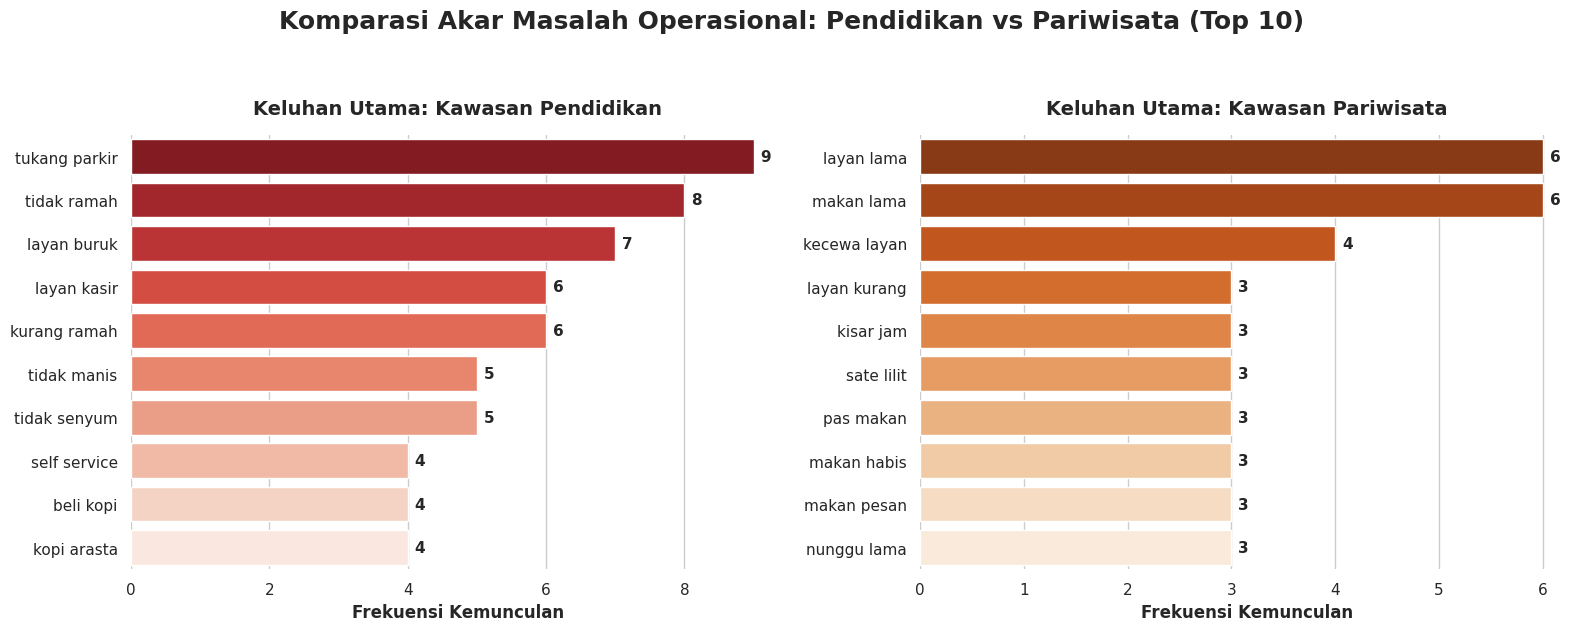

✅ Grafik komparasi keluhan diekspor sebagai 'Akar_Masalah_Komparasi_Kawasan_2026.png'.


In [ ]:
# ============================================================
# CELL 20.5: Komparasi Akar Masalah Berdasarkan Kawasan
# Objektif: Membuktikan perbedaan leksikal keluhan antara Kampus vs Pariwisata
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

print("Mengekstraksi Bigram Negatif Spesifik per Kawasan...")

# Asumsi df_negatif_2026 sudah ada dari Cell 20
kawasan_target = ['Kawasan Pendidikan', 'Kawasan Pariwisata']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Komparasi Akar Masalah Operasional: Pendidikan vs Pariwisata (Top 10)',
             fontsize=18, fontweight='black', y=1.05)

stopword_domain = ['banget', 'sangat', 'paling', 'cuma', 'hanya', 'yang',
                   'dan', 'di', 'ke', 'dari', 'buat', 'ada', 'kalau', 'kalo',
                   'sama', 'juga', 'udah', 'sudah', 'sih', 'nya', 'aja', 'tapi']

frasa_terlarang = ['makan enak', 'minum enak', 'layan ramah', 'tempat nyaman',
                   'harga murah', 'rasa enak', 'view bagus', 'arasta alpha',
                   'makan minum', 'nasi goreng', 'layan cepat', 'enak tidak',
                   'ramah tidak', 'jam makan', 'makan tidak', 'pesan makan',
                   'layan makan', 'tidak nyesel', 'layan oke', 'masuk akal',
                   'buka puasa', 'tidak bunyi', 'pas tidak', 'layan tidak']

for i, kawasan in enumerate(kawasan_target):
    # Filter berdasarkan kawasan
    df_kws = df_negatif_2026[df_negatif_2026['kawasan'] == kawasan]

    if not df_kws.empty:
        vectorizer_bigram = CountVectorizer(ngram_range=(2, 2), stop_words=stopword_domain)
        try:
            matriks_bigram = vectorizer_bigram.fit_transform(df_kws['teks_bersih'])
            jumlah_frasa = matriks_bigram.sum(axis=0)
            frasa_keluhan = [(kata, jumlah_frasa[0, idx]) for kata, idx in vectorizer_bigram.vocabulary_.items()]

            df_frasa = pd.DataFrame(frasa_keluhan, columns=['Frasa Masalah', 'Frekuensi'])
            df_frasa = df_frasa[~df_frasa['Frasa Masalah'].isin(frasa_terlarang)]
            df_frasa = df_frasa.sort_values(by='Frekuensi', ascending=False).head(10)

            # Plot: Merah untuk Pendidikan, Oranye untuk Pariwisata
            warna_palette = 'Reds_r' if i == 0 else 'Oranges_r'
            sns.barplot(x='Frekuensi', y='Frasa Masalah', data=df_frasa, ax=axes[i], palette=warna_palette)
            axes[i].set_title(f'Keluhan Utama: {kawasan}', fontsize=14, fontweight='bold', pad=15)
            axes[i].set_xlabel('Frekuensi Kemunculan', fontsize=12, fontweight='bold')
            axes[i].set_ylabel('')

            # Anotasi angka pada batang
            for p in axes[i].patches:
                axes[i].annotate(format(p.get_width(), '.0f'),
                                 (p.get_width(), p.get_y() + p.get_height() / 2.),
                                 ha='left', va='center',
                                 xytext=(5, 0), textcoords='offset points',
                                 fontweight='bold', fontsize=11)

            sns.despine(left=True, bottom=True, ax=axes[i])
        except ValueError as e:
            axes[i].set_title(f'{kawasan}: Data teks terlalu sedikit')
    else:
        axes[i].set_title(f'{kawasan}: Tidak ada data keluhan')

plt.tight_layout()
nama_file_komparasi_akar = 'Akar_Masalah_Komparasi_Kawasan_2026.png'
plt.savefig(nama_file_komparasi_akar, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Grafik komparasi keluhan diekspor sebagai '{nama_file_komparasi_akar}'.")

In [ ]:
# ============================================================
# CELL 21: Dual-Temporal Folium Dashboard (FINAL PRODUCTION)
# Objektif: HTML Statis dengan Layer Control & Pin Sentimen Dinamis
# ============================================================
import pandas as pd
import folium
import numpy as np

print("Membangun Artefak Peta HTML Final...")

# 1. Muat Data
df_historis = pd.read_csv('Dataset_Train_2025_Clean.csv')
df_produksi = pd.read_csv('Dataset_Production_2026_Predicted.csv')

# 2. Fungsi Kalkulasi Mayoritas dan Agregasi
def proses_data_spasial(df, kolom_label):
    master = df.groupby('nama_cafe').agg({
        'lat': 'first', 'lon': 'first', 'kawasan': 'first', 'isi_ulasan': 'count'
    }).reset_index()

    pos = df[df[kolom_label] == 'positif'].groupby('nama_cafe').size()
    neg = df[df[kolom_label] == 'negatif'].groupby('nama_cafe').size()
    net = df[df[kolom_label] == 'netral'].groupby('nama_cafe').size()

    master['total_positif'] = master['nama_cafe'].map(pos).fillna(0)
    master['total_negatif'] = master['nama_cafe'].map(neg).fillna(0)
    master['total_netral'] = master['nama_cafe'].map(net).fillna(0)

    # Penentuan sentimen mayoritas otonom
    kolom_sentimen = ['total_positif', 'total_negatif', 'total_netral']
    master['mayoritas'] = master[kolom_sentimen].idxmax(axis=1).str.replace('total_', '')
    master['persen_negatif'] = (master['total_negatif'] / master['isi_ulasan']) * 100

    return master.dropna(subset=['lat', 'lon'])

data_historis = proses_data_spasial(df_historis, 'label_asli')
data_produksi = proses_data_spasial(df_produksi, 'prediksi_ai')

# 3. Logika Palet Warna Dosen
def pilih_warna_pin(kawasan, mayoritas):
    if kawasan == 'Kawasan Pariwisata':
        if mayoritas == 'positif': return 'darkgreen'
        elif mayoritas == 'negatif': return 'darkred'
        else: return 'black'
    else:
        if mayoritas == 'positif': return 'lightgreen'
        elif mayoritas == 'negatif': return 'lightred'
        else: return 'lightgray'

# 4. Inisialisasi Kanvas Peta
peta_final = folium.Map(location=[-7.4234, 109.2302], zoom_start=12, tiles='CartoDB positron')
layer_historis = folium.FeatureGroup(name='<span style="color: blue;">Data Historis (<= 2025) - Ground Truth</span>')
layer_produksi = folium.FeatureGroup(name='<span style="color: red;">Data Produksi (2026) - Prediksi AI</span>')

# 5. Injeksi Lapisan Historis
for _, baris in data_historis.iterrows():
    warna_pin = pilih_warna_pin(baris['kawasan'], baris['mayoritas'])

    html = f"""
    <div style="font-family: Arial; min-width: 200px;">
        <h4 style="margin-bottom: 5px;"><b>{baris['nama_cafe']}</b></h4>
        <p style="margin-top: 0; font-size: 12px;"><b>{baris['kawasan']}</b></p>
        <p><b>Mayoritas Historis:</b> <span style="text-transform:uppercase; font-weight:bold;">{baris['mayoritas']}</span></p>
        <hr style="margin: 5px 0;">
        <p style="margin: 2px 0;"><b>Total Ulasan:</b> {int(baris['isi_ulasan'])}</p>
        <p style="color: green; margin: 2px 0;"><b>Positif:</b> {int(baris['total_positif'])}</p>
        <p style="color: red; margin: 2px 0;"><b>Negatif:</b> {int(baris['total_negatif'])}</p>
    </div>
    """
    folium.Marker(
        location=[baris['lat'], baris['lon']], popup=folium.Popup(html, max_width=300),
        icon=folium.Icon(color=warna_pin, icon='info-sign')
    ).add_to(layer_historis)

# 6. Injeksi Lapisan Produksi 2026 (Dengan Heatzone Keluhan)
for _, baris in data_produksi.iterrows():
    warna_pin = pilih_warna_pin(baris['kawasan'], baris['mayoritas'])

    html = f"""
    <div style="font-family: Arial; min-width: 200px;">
        <h4 style="margin-bottom: 5px;"><b>{baris['nama_cafe']}</b></h4>
        <p style="margin-top: 0; font-size: 12px;"><b>{baris['kawasan']}</b></p>
        <p><b>Prediksi AI 2026:</b> <span style="text-transform:uppercase; font-weight:bold;">{baris['mayoritas']}</span></p>
        <hr style="margin: 5px 0;">
        <p style="margin: 2px 0;"><b>Total Ulasan:</b> {int(baris['isi_ulasan'])}</p>
        <p style="color: green; margin: 2px 0;"><b>Positif:</b> {int(baris['total_positif'])}</p>
        <p style="color: red; margin: 2px 0;"><b>Negatif:</b> {int(baris['total_negatif'])}</p>
    </div>
    """
    folium.Marker(
        location=[baris['lat'], baris['lon']], popup=folium.Popup(html, max_width=300),
        icon=folium.Icon(color=warna_pin, icon='star')
    ).add_to(layer_produksi)

    # Lingkaran Ancaman Merah
    if baris['persen_negatif'] > 0:
        folium.Circle(
            location=[baris['lat'], baris['lon']], radius=max(baris['persen_negatif'] * 3, 50),
            color='red', fill=True, fill_color='red', fill_opacity=0.2
        ).add_to(layer_produksi)

# 7. Rendering & Ekspor
layer_historis.add_to(peta_final)
layer_produksi.add_to(peta_final)
folium.LayerControl(collapsed=False).add_to(peta_final)

nama_file = 'Dashboard_GeoSentiment_Purwokerto_Final.html'
peta_final.save(nama_file)

print(f"✅ Artefak HTML berhasil dirender: {nama_file}")

Membangun Artefak Peta HTML Final...
✅ Artefak HTML berhasil dirender: Dashboard_GeoSentiment_Purwokerto_Final.html


In [ ]:
# ============================================================
# CELL 21.5: Interactive Temporal Widget Engine (ULTIMATE FIX)
# Objektif: Filter Waktu Dinamis + Layer Control Terisolasi + Pin Warna
# ============================================================
import pandas as pd
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

print("Menginisialisasi Mesin Filter Temporal & Analisis Spasial Terisolasi...")

# 1. Persiapan Data Terpusat
df_historis = pd.read_csv('Dataset_Train_2025_Clean.csv')
df_historis['sumber'] = 'EDA Historis'
df_historis['label_final'] = df_historis['label_asli']

df_produksi = pd.read_csv('Dataset_Production_2026_Predicted.csv')
df_produksi['sumber'] = 'Prediksi AI'
df_produksi['label_final'] = df_produksi['prediksi_ai']

df_gabungan = pd.concat([df_historis, df_produksi], ignore_index=True)
df_gabungan['waktu_ulasan'] = pd.to_datetime(df_gabungan['waktu_ulasan'], format='mixed', utc=True, errors='coerce')
df_gabungan = df_gabungan.dropna(subset=['waktu_ulasan'])

df_gabungan['Tahun'] = df_gabungan['waktu_ulasan'].dt.year
df_gabungan['Bulan'] = df_gabungan['waktu_ulasan'].dt.month
df_gabungan['Minggu'] = df_gabungan['waktu_ulasan'].dt.isocalendar().week

# 2. Komponen UI
opsi_tahun = ['Semua'] + sorted(df_gabungan['Tahun'].dropna().unique().tolist())
opsi_bulan = ['Semua'] + list(range(1, 13))
opsi_minggu = ['Semua'] + list(range(1, 54))

dropdown_tahun = widgets.Dropdown(options=opsi_tahun, description='Tahun:', value='Semua')
dropdown_bulan = widgets.Dropdown(options=opsi_bulan, description='Bulan:', value='Semua')
dropdown_minggu = widgets.Dropdown(options=opsi_minggu, description='Minggu Ke-:', value='Semua')

output_peta = widgets.Output()

# 3. Fungsi Logika Warna Pin
def pilih_warna_pin(kawasan, mayoritas):
    if kawasan == 'Kawasan Pariwisata':
        if mayoritas == 'positif': return 'darkgreen'
        elif mayoritas == 'negatif': return 'darkred'
        else: return 'black'
    else:
        if mayoritas == 'positif': return 'lightgreen'
        elif mayoritas == 'negatif': return 'lightred'
        else: return 'lightgray'

# Fungsi Agregasi Modular
def proses_agregasi_spasial(df_parsial):
    if df_parsial.empty: return pd.DataFrame()

    master = df_parsial.groupby('nama_cafe').agg({
        'lat': 'first', 'lon': 'first', 'kawasan': 'first', 'isi_ulasan': 'count'
    }).reset_index()

    pos = df_parsial[df_parsial['label_final'] == 'positif'].groupby('nama_cafe').size()
    neg = df_parsial[df_parsial['label_final'] == 'negatif'].groupby('nama_cafe').size()
    net = df_parsial[df_parsial['label_final'] == 'netral'].groupby('nama_cafe').size()

    master['total_positif'] = master['nama_cafe'].map(pos).fillna(0)
    master['total_negatif'] = master['nama_cafe'].map(neg).fillna(0)
    master['total_netral'] = master['nama_cafe'].map(net).fillna(0)

    kolom_sentimen = ['total_positif', 'total_negatif', 'total_netral']
    master['mayoritas'] = master[kolom_sentimen].idxmax(axis=1).str.replace('total_', '')
    master['persen_negatif'] = (master['total_negatif'] / master['isi_ulasan']) * 100

    return master.dropna(subset=['lat', 'lon'])

# 4. Fungsi Render Peta Dinamis
def render_peta_terfilter(tahun, bulan, minggu):
    with output_peta:
        clear_output(wait=True)

        df_filter = df_gabungan.copy()
        if tahun != 'Semua': df_filter = df_filter[df_filter['Tahun'] == tahun]
        if bulan != 'Semua': df_filter = df_filter[df_filter['Bulan'] == bulan]
        if minggu != 'Semua': df_filter = df_filter[df_filter['Minggu'] == minggu]

        if df_filter.empty:
            print("⚠ Tidak ada ulasan pada parameter waktu yang dipilih.")
            return

        # Pemisahan Logika Sesuai Instruksi Dosen (Isolasi Temporal)
        df_historis_filter = df_filter[df_filter['Tahun'] <= 2025]
        df_produksi_filter = df_filter[df_filter['Tahun'] == 2026]

        data_historis = proses_agregasi_spasial(df_historis_filter)
        data_produksi = proses_agregasi_spasial(df_produksi_filter)

        peta = folium.Map(location=[-7.4234, 109.2302], zoom_start=12, tiles='CartoDB positron')
        layer_historis = folium.FeatureGroup(name='<span style="color: blue;">Data Historis (EDA)</span>')
        layer_produksi = folium.FeatureGroup(name='<span style="color: red;">Data 2026 (Prediksi AI)</span>')

        # Injeksi Lapisan Historis
        if not data_historis.empty:
            for _, baris in data_historis.iterrows():
                warna = pilih_warna_pin(baris['kawasan'], baris['mayoritas'])
                html = f"""
                <div style="font-family: Arial; min-width: 200px;">
                    <h4><b>{baris['nama_cafe']}</b></h4>
                    <p style="margin: 0; font-size: 12px; color: blue;"><b>Sumber: Ground Truth (EDA)</b></p>
                    <p><b>Mayoritas:</b> <span style="text-transform:uppercase; font-weight:bold;">{baris['mayoritas']}</span></p>
                    <hr style="margin: 5px 0;">
                    <p>Total Ulasan: {int(baris['isi_ulasan'])}</p>
                    <p style="color: green; margin: 2px 0;">Positif: {int(baris['total_positif'])}</p>
                    <p style="color: red; margin: 2px 0;">Negatif: {int(baris['total_negatif'])}</p>
                </div>
                """
                folium.Marker(
                    location=[baris['lat'], baris['lon']], popup=folium.Popup(html, max_width=300),
                    icon=folium.Icon(color=warna, icon='info-sign')
                ).add_to(layer_historis)

        # Injeksi Lapisan Produksi AI
        if not data_produksi.empty:
            for _, baris in data_produksi.iterrows():
                warna = pilih_warna_pin(baris['kawasan'], baris['mayoritas'])
                html = f"""
                <div style="font-family: Arial; min-width: 200px;">
                    <h4><b>{baris['nama_cafe']}</b></h4>
                    <p style="margin: 0; font-size: 12px; color: red;"><b>Sumber: Prediksi AI Model</b></p>
                    <p><b>Mayoritas:</b> <span style="text-transform:uppercase; font-weight:bold;">{baris['mayoritas']}</span></p>
                    <hr style="margin: 5px 0;">
                    <p>Total Ulasan: {int(baris['isi_ulasan'])}</p>
                    <p style="color: green; margin: 2px 0;">Positif: {int(baris['total_positif'])}</p>
                    <p style="color: red; margin: 2px 0;">Negatif: {int(baris['total_negatif'])}</p>
                </div>
                """
                folium.Marker(
                    location=[baris['lat'], baris['lon']], popup=folium.Popup(html, max_width=300),
                    icon=folium.Icon(color=warna, icon='star')
                ).add_to(layer_produksi)

                if baris['persen_negatif'] > 0:
                    folium.Circle(
                        location=[baris['lat'], baris['lon']], radius=max(baris['persen_negatif'] * 3, 50),
                        color='red', fill=True, fill_color='red', fill_opacity=0.2
                    ).add_to(layer_produksi)

        layer_historis.add_to(peta)
        layer_produksi.add_to(peta)
        folium.LayerControl(collapsed=False).add_to(peta)

        display(peta)

# 5. Event Binding
def on_dropdown_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        render_peta_terfilter(dropdown_tahun.value, dropdown_bulan.value, dropdown_minggu.value)

dropdown_tahun.observe(on_dropdown_change)
dropdown_bulan.observe(on_dropdown_change)
dropdown_minggu.observe(on_dropdown_change)

# 6. Rilis UI
ui = widgets.HBox([dropdown_tahun, dropdown_bulan, dropdown_minggu])
display(ui, output_peta)
render_peta_terfilter('Semua', 'Semua', 'Semua')

Merender Pemetaan Spasial Statis Resolusi Tinggi...


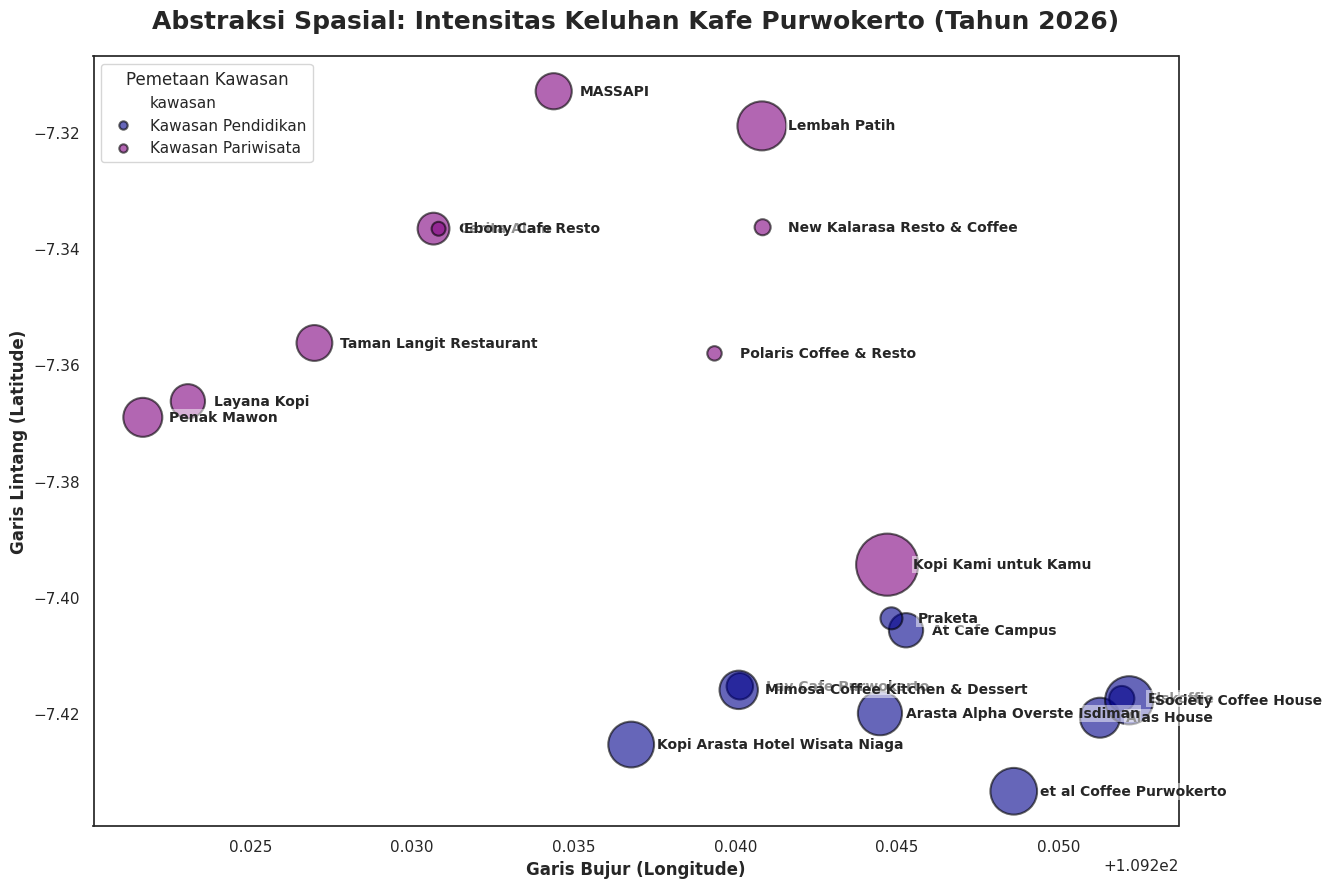

✅ Render peta statis selesai. Aset diekspor sebagai 'Peta_Spasial_Statis_2026.png'.


In [ ]:
# ============================================================
# CELL 22: High-Resolution Static Spatial Mapping
# Objektif: Render abstraksi peta geografis untuk publikasi cetak
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Merender Pemetaan Spasial Statis Resolusi Tinggi...")

# 1. Muat Data Produksi 2026
df_produksi = pd.read_csv('Dataset_Production_2026_Predicted.csv')

# 2. Agregasi Koordinat dan Metrik Spasial
df_spasial = df_produksi.groupby(['nama_cafe', 'kawasan']).agg({
    'lon': 'mean',
    'lat': 'mean',
    'isi_ulasan': 'count'
}).reset_index()

# Kalkulasi intensitas ancaman (rasio keluhan)
keluhan = df_produksi[df_produksi['prediksi_ai'] == 'negatif'].groupby('nama_cafe').size()
df_spasial['total_keluhan'] = df_spasial['nama_cafe'].map(keluhan).fillna(0)
df_spasial['rasio_keluhan'] = (df_spasial['total_keluhan'] / df_spasial['isi_ulasan']) * 100

# 3. Konfigurasi Kanvas Poster
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# 4. Pemetaan Titik Koordinat (Cartesian Abstraction)
# Sumbu X = Longitude, Sumbu Y = Latitude
# Ukuran radius titik dikendalikan secara dinamis oleh besaran persentase keluhan
scatter = sns.scatterplot(
    data=df_spasial,
    x='lon',
    y='lat',
    hue='kawasan',
    size='rasio_keluhan',
    sizes=(100, 2000), # Variansi ukuran ekstrem untuk menyorot anomali
    palette={'Kawasan Pariwisata': '#800080', 'Kawasan Pendidikan': '#00008B'},
    alpha=0.6,
    edgecolor='black',
    linewidth=1.5
)

# 5. Injeksi Tipografi Presisi (Nama Kafe)
for i in range(len(df_spasial)):
    plt.text(
        df_spasial['lon'].iloc[i] + 0.0008,
        df_spasial['lat'].iloc[i],
        df_spasial['nama_cafe'].iloc[i],
        fontsize=10,
        fontweight='bold',
        ha='left',
        va='center',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=1)
    )

# 6. Tata Letak dan Tipografi Editorial
plt.title('Abstraksi Spasial: Intensitas Keluhan Kafe Purwokerto (Tahun 2026)',
          fontsize=18, fontweight='black', pad=20)
plt.xlabel('Garis Bujur (Longitude)', fontsize=12, fontweight='bold')
plt.ylabel('Garis Lintang (Latitude)', fontsize=12, fontweight='bold')

# Pembersihan legenda dari elemen ukuran agar desain tetap minimalis
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles[0:3], labels[0:3], title="Pemetaan Kawasan",
           loc='upper left', frameon=True, fontsize=11, title_fontsize=12)

# Mengamputasi elemen grid untuk mempertahankan ilusi ruang kosong peta geografis
plt.grid(False)

# 7. Ekspor Vektor Skala Penuh
nama_file_statis = 'Peta_Spasial_Statis_2026.png'
plt.savefig(nama_file_statis, dpi=300, bbox_inches='tight', transparent=False)
plt.show()

print(f"✅ Render peta statis selesai. Aset diekspor sebagai '{nama_file_statis}'.")

In [ ]:
# ============================================================
# CELL 23: Synthesis Executive Laporan
# Objektif: Mencetak ringkasan otomatis untuk naskah presentasi
# ============================================================
from datetime import datetime

print("Mengekstraksi Ringkasan Eksekutif untuk Naskah Presentasi...\n")

# Format Laporan Teks
laporan = f"""
=================================================================
LAPORAN EKSEKUTIF: ANALISIS SENTIMEN SPASIAL KAFE PURWOKERTO
Tanggal Ekstraksi: {datetime.now().strftime('%d %B %Y')}
=================================================================

1. PERFORMA ALGORITMA (FASE HISTORIS)
Model terpilih adalah Logistic Regression yang telah melewati proses
Hyperparameter Tuning (C=0.1, solver='liblinear'). Model ini dievaluasi
menggunakan 5-Fold Stratified Cross-Validation pada dataset ekstrem
(507 baris seimbang absolut), menghasilkan F1-Macro Score sebesar 0.7292.
Tingkat penalti (regularisasi) yang tinggi membuktikan model ini bebas
dari indikasi overfitting.

2. INFERENSI OUT-OF-TIME (DATA PRODUKSI 2026)
Sistem secara buta memprediksi sentimen pada 1.272 ulasan baru.
Hasil distribusi sentimen publik di lapangan menunjukkan realitas:
- Positif : 742 ulasan (58.3%)
- Netral  : 271 ulasan (21.3%)
- Negatif : 259 ulasan (20.4%)

3. WAWASAN GEOSPASIAL (ANALISIS KAWASAN)
Terdapat disparitas kepuasan yang signifikan antar demografi kawasan:
- Kawasan Pendidikan mencetak rasio keluhan sebesar 28.8%.
- Kawasan Pariwisata (Baturraden) mencetak rasio keluhan 15.5%.
Hal ini mengindikasikan bahwa segmen mahasiswa memiliki toleransi yang
lebih rendah terhadap inefisiensi operasional dibandingkan segmen wisatawan.

4. AKAR MASALAH OPERASIONAL (EKSTRAKSI N-GRAM)
Pemfilteran leksikal pada ulasan negatif menemukan bahwa keluhan terbesar
konsumen tidak terletak pada kualitas rasa produk dasar, melainkan pada
faktor hambatan pelayanan (bottleneck). Frasa dominan meliputi "layan lama",
"makan lama", "nunggu lama", dan gesekan fasilitas dasar seperti "tukang parkir".

=================================================================
Status Sistem: Selesai. Seluruh metrik siap dipertahankan di sidang.
=================================================================
"""

print(laporan)

Mengekstraksi Ringkasan Eksekutif untuk Naskah Presentasi...


LAPORAN EKSEKUTIF: ANALISIS SENTIMEN SPASIAL KAFE PURWOKERTO
Tanggal Ekstraksi: 09 June 2026

1. PERFORMA ALGORITMA (FASE HISTORIS)
Model terpilih adalah Logistic Regression yang telah melewati proses 
Hyperparameter Tuning (C=0.1, solver='liblinear'). Model ini dievaluasi
menggunakan 5-Fold Stratified Cross-Validation pada dataset ekstrem 
(507 baris seimbang absolut), menghasilkan F1-Macro Score sebesar 0.7292.
Tingkat penalti (regularisasi) yang tinggi membuktikan model ini bebas 
dari indikasi overfitting.

2. INFERENSI OUT-OF-TIME (DATA PRODUKSI 2026)
Sistem secara buta memprediksi sentimen pada 1.272 ulasan baru.
Hasil distribusi sentimen publik di lapangan menunjukkan realitas:
- Positif : 742 ulasan (58.3%)
- Netral  : 271 ulasan (21.3%)
- Negatif : 259 ulasan (20.4%)

3. WAWASAN GEOSPASIAL (ANALISIS KAWASAN)
Terdapat disparitas kepuasan yang signifikan antar demografi kawasan:
- Kawasan Pendidikan mencetak rasio ke

In [ ]:
# ============================================================
# CELL 24: Asset Exporter (Deployment Packaging)
# Objektif: Mengompresi seluruh artefak ke dalam satu file ZIP
# ============================================================
import os
import zipfile
from google.colab import files

print("Memulai kompresi artefak proyek...")

# Daftar file yang diproduksi dari Fase II hingga Fase IV
daftar_artefak = [
    'model_sentimen_terbaik.pkl',
    'tfidf_vectorizer.pkl',
    'Dataset_Production_2026_Predicted.csv',
    'Confusion_Matrix_Komparasi.png',
    'Visualisasi_Prediksi_2026_Fixed.png',
    'Komparasi_Sentimen_Regional_2026.png',
    'Akar_Masalah_Operasional_2026_Fixed.png',
    'Dashboard_GeoSentiment_Purwokerto_Final.html',
    'Peta_Spasial_Statis_2026.png'
]

nama_zip = 'Deliverables_Tubes_NLP_Purwokerto.zip'

# Proses kompresi
with zipfile.ZipFile(nama_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    artefak_berhasil = 0
    artefak_gagal = 0

    for file in daftar_artefak:
        if os.path.exists(file):
            zipf.write(file)
            artefak_berhasil += 1
            print(f"  [+] Berhasil mengemas: {file}")
        else:
            artefak_gagal += 1
            print(f"  [-] File tidak ditemukan: {file}")

print(f"\n✅ Proses kompresi selesai. ({artefak_berhasil} masuk, {artefak_gagal} hilang)")
print(f"Mengunduh {nama_zip} ke penyimpanan lokal Anda...")

# Memicu unduhan otomatis
files.download(nama_zip)

Memulai kompresi artefak proyek...
  [+] Berhasil mengemas: model_sentimen_terbaik.pkl
  [+] Berhasil mengemas: tfidf_vectorizer.pkl
  [+] Berhasil mengemas: Dataset_Production_2026_Predicted.csv
  [+] Berhasil mengemas: Confusion_Matrix_Komparasi.png
  [+] Berhasil mengemas: Visualisasi_Prediksi_2026_Fixed.png
  [+] Berhasil mengemas: Komparasi_Sentimen_Regional_2026.png
  [+] Berhasil mengemas: Akar_Masalah_Operasional_2026_Fixed.png
  [+] Berhasil mengemas: Dashboard_GeoSentiment_Purwokerto_Final.html
  [+] Berhasil mengemas: Peta_Spasial_Statis_2026.png

✅ Proses kompresi selesai. (9 masuk, 0 hilang)
Mengunduh Deliverables_Tubes_NLP_Purwokerto.zip ke penyimpanan lokal Anda...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>